In [1]:
import ast
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib import cm
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import xarray as xr
from shapely.geometry import mapping, shape, MultiPolygon, box, Point
from affine import Affine
import rasterio
from shapely import wkt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import logging
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches  # Import for custom legend
from dotenv import load_dotenv
import os
from pathlib import Path
import json
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd
from scipy.stats import zscore
from scipy.stats import zscore
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import gaussian_filter
from rioxarray.exceptions import NoDataInBounds  # Import NoDataInBounds exception
from pathlib import Path
import os
import itertools
import logging
import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

# Set font sizes for various components
plt.rcParams.update({
    'font.size': 16,           # Global font size
    'axes.titlesize': 24,      # Title font size
    'axes.labelsize': 24,      # X and Y label font size
    'xtick.labelsize': 16,     # X tick label font size
    'ytick.labelsize': 16,     # Y tick label font size
})

# Importing specific functions from the module
from func_preprocessing import restructure_dataset, remove_outliers, smooth
from func_indecies import ndvi, nbr, ndwi, ndre, tcw, tcg, tcb, ndmi, nirv, kndvi, drs, ndrs, kdrs, kndrs
from func_helper import parse_custom_colors, format_label
from func_file_io import load_data

In [41]:
ids_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region_08_dca_filtered_ids_usda_polygons.shp"
ids = gpd.read_file(ids_new)
ids = ids[ids['DCA_ID'] == 'wind']
ids = ids[ids['SURVEY_Y'] == 2020]
import geopandas as gpd

# Select 10 random examples
ids_random10 = ids.sample(n=10, random_state=42)  # random_state ensures reproducibility
ids_random10
# Save as a new shapefile
ids_random10.to_file("/net/projects/forexd/WP1/Data/random_manual_sample_files/wind/ids_random10.shp")

✅ Found 10 IDS polygons with matches in S1DM.
📊 Sampling 10 polygons for plotting.
✅ Selected 10 IDS samples, matched 35 S1DM geometries.


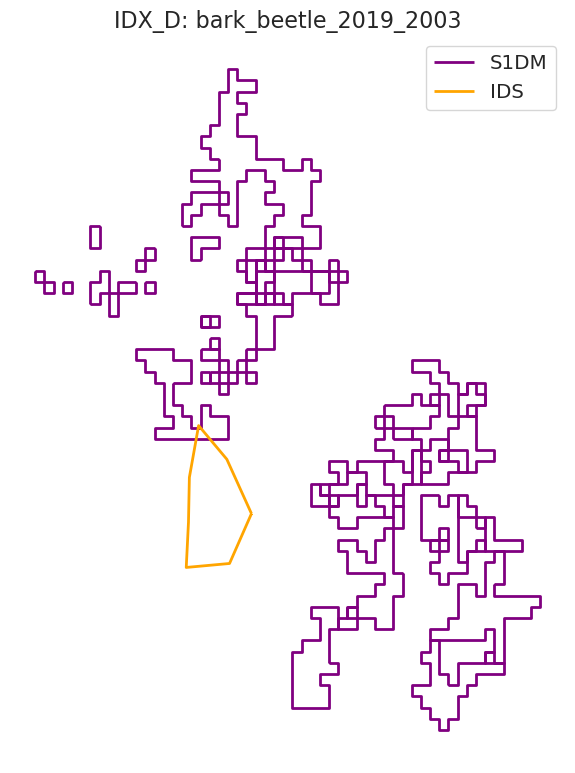

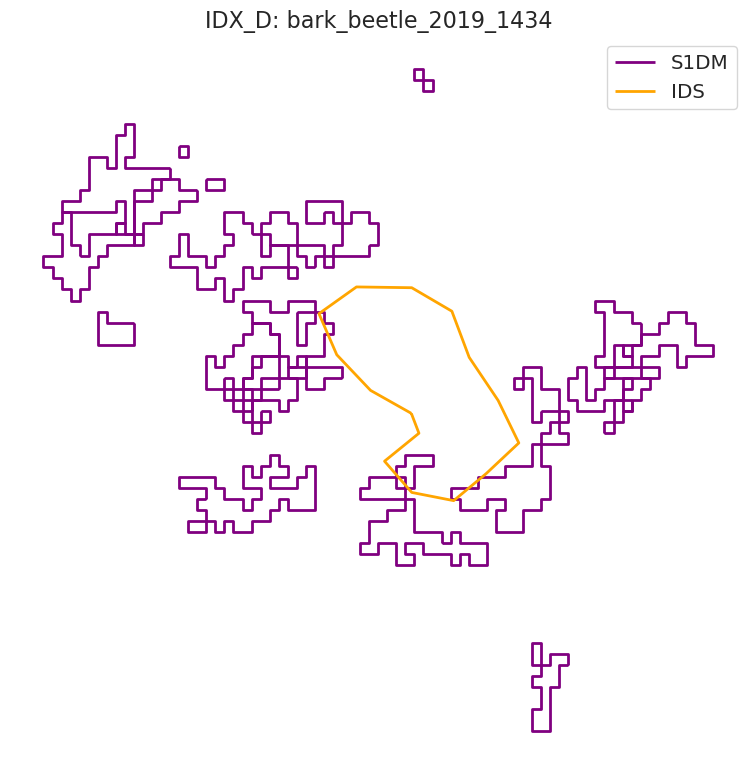

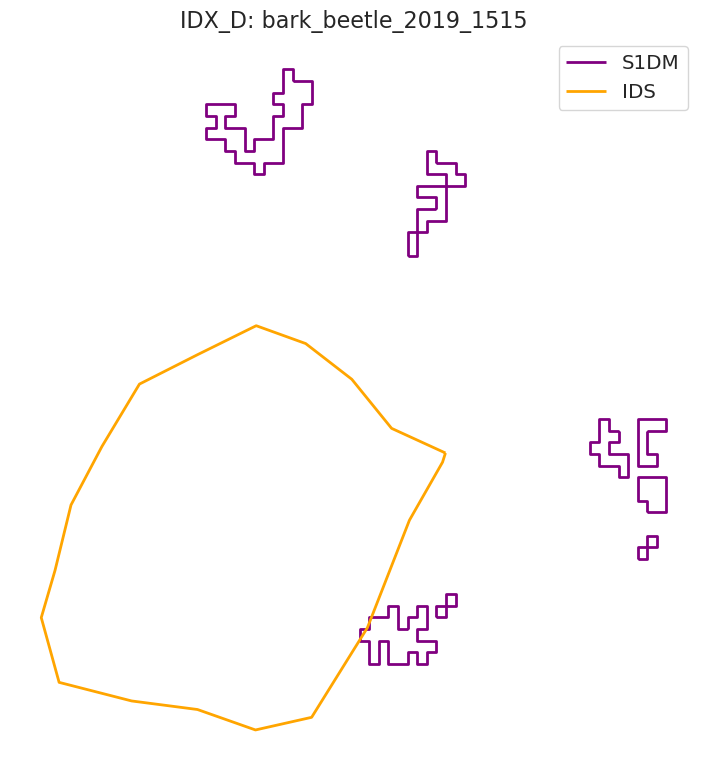

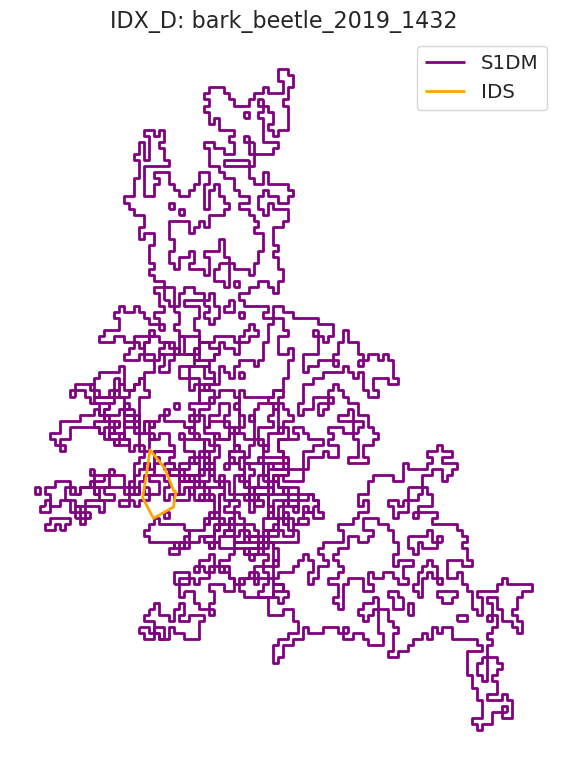

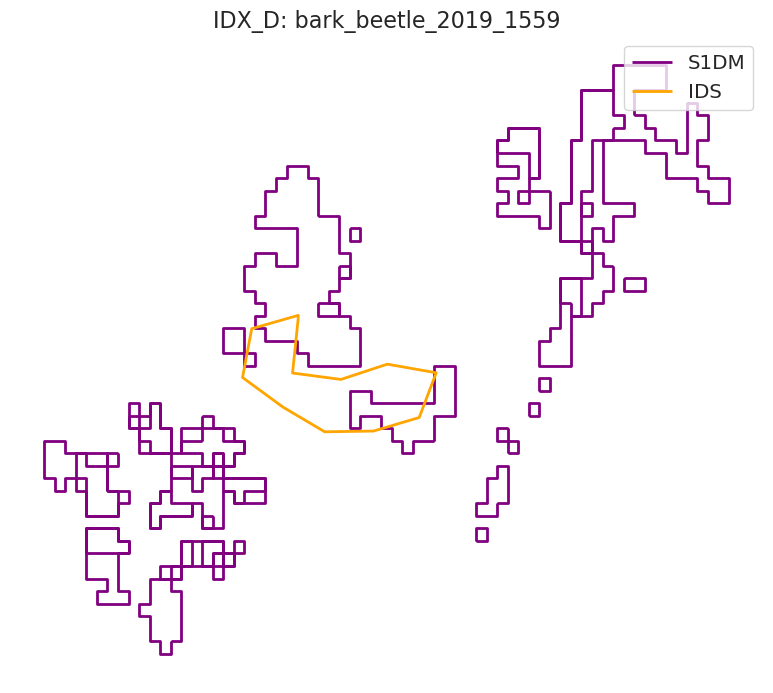

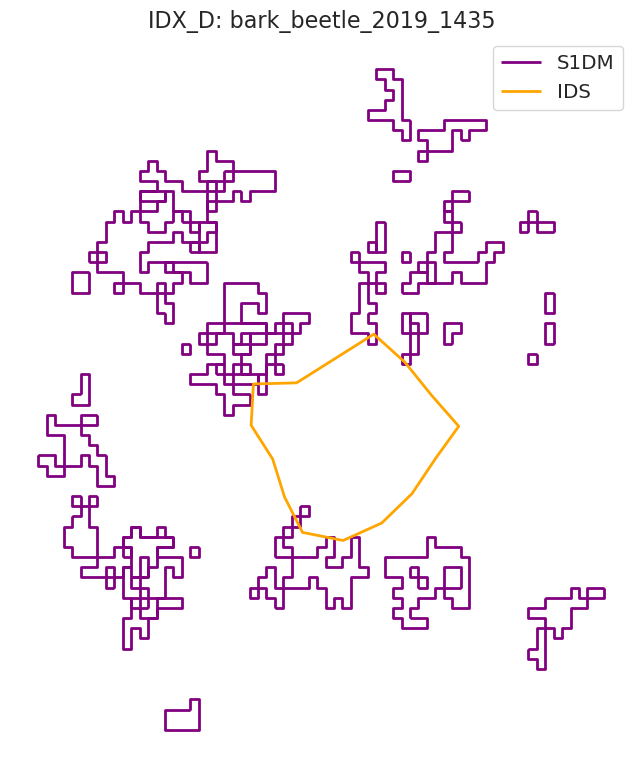

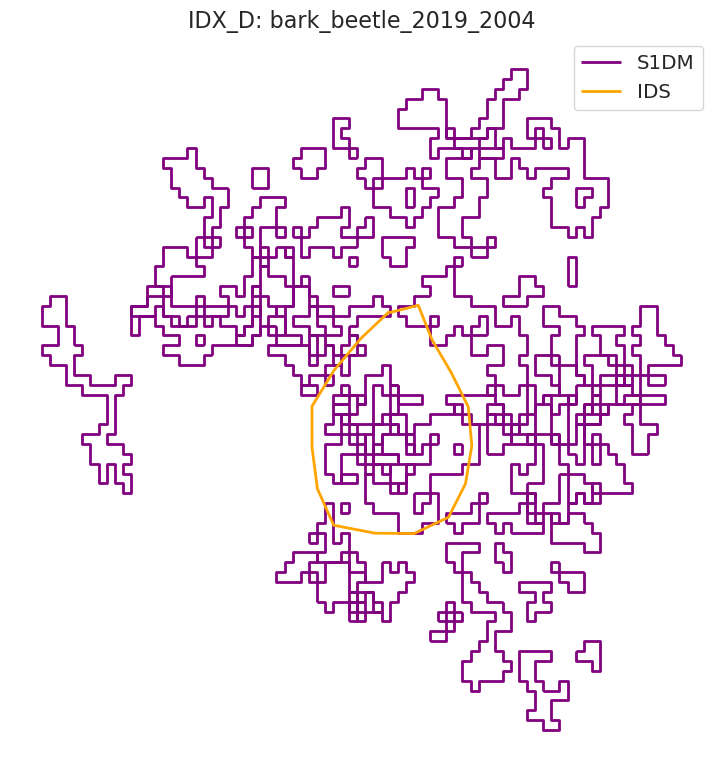

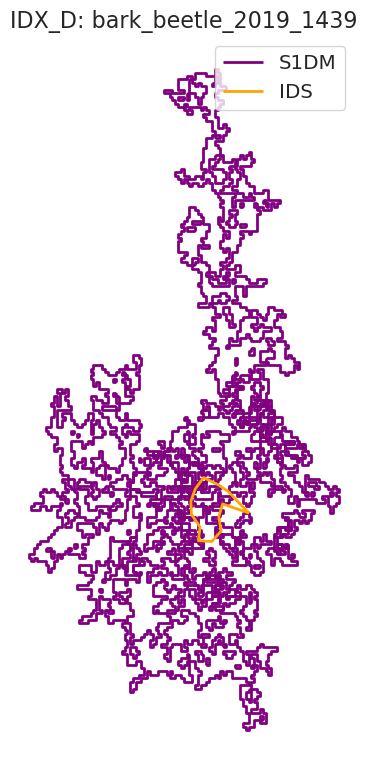

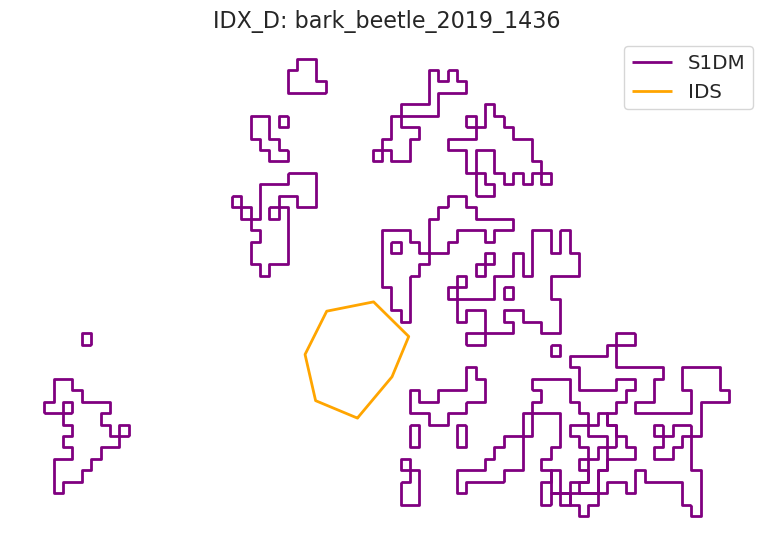

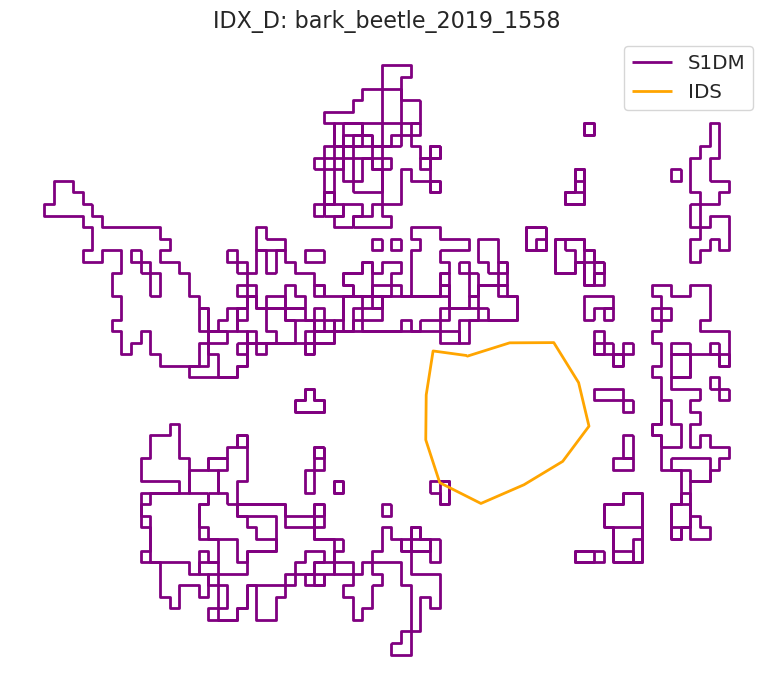

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# --- File paths ---
ids_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region_08_dca_filtered_ids_usda_polygons.shp"
s1dm_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"

# --- Load data ---
ids = gpd.read_file(ids_new)
s1dm = gpd.read_file(s1dm_new)

# --- Filter for Bark Beetle 2020 ---
ids = ids[(ids['DCA_ID'] == 'bark_beetle') & (ids['SURVEY_Y'] == 2019)]

# --- Keep only IDS polygons that exist in S1DM ---
common_idx = ids["IDX_D"].isin(s1dm["IDX_D"])
ids_filtered = ids[common_idx]

print(f"✅ Found {len(ids_filtered)} IDS polygons with matches in S1DM.")

# --- Determine how many samples we can take ---
n_samples = min(10, len(ids_filtered))
print(f"📊 Sampling {n_samples} polygons for plotting.")

# --- Select random examples ---
ids_random = ids_filtered.sample(n=n_samples, random_state=42)

# --- Save random sample ---
out_dir = "/net/projects/forexd/WP1/Data/random_manual_sample_files/bark_beetle"
os.makedirs(out_dir, exist_ok=True)
ids_random.to_file(os.path.join(out_dir, "ids_random_sample.shp"))

# --- Get corresponding S1DM geometries ---
idx_list = ids_random["IDX_D"].unique().tolist()
s1dm_matched = s1dm[s1dm["IDX_D"].isin(idx_list)]

print(f"✅ Selected {len(ids_random)} IDS samples, matched {len(s1dm_matched)} S1DM geometries.")

# --- Plot IDS vs S1DM for each matched IDX_D ---
for idx in idx_list:
    subset_ids = ids_random[ids_random["IDX_D"] == idx]
    subset_s1dm = s1dm_matched[s1dm_matched["IDX_D"] == idx]

    fig, ax = plt.subplots(figsize=(8, 8))
    subset_s1dm.boundary.plot(ax=ax, color="purple", linewidth=2, label="S1DM")
    subset_ids.boundary.plot(ax=ax, color="orange", linewidth=2, label="IDS")

    ax.set_title(f"IDX_D: {idx}", fontsize=16)
    ax.legend()
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


Matched 37 S1DM geometries for 10 IDS samples
✅ Saved convex hull polygons to: /net/projects/forexd/WP1/Data/random_manual_sample_files/wind/ids_s1dm_convex_hulls.shp


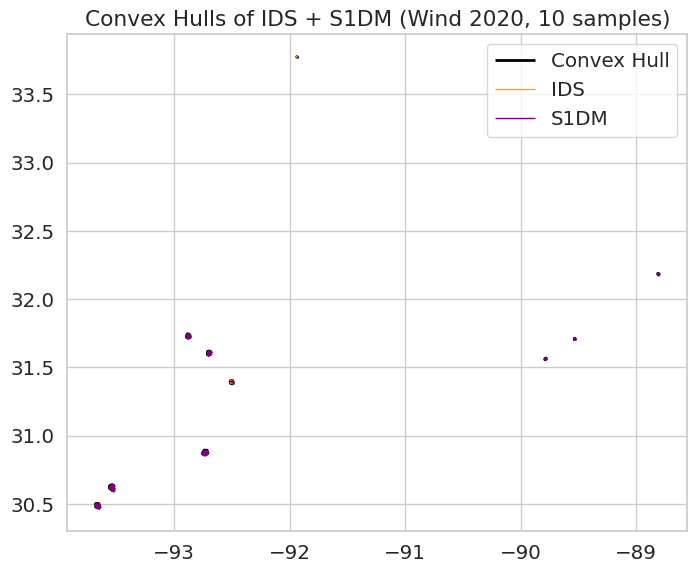

In [45]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union
import os

# --- File paths ---
ids_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region_08_dca_filtered_ids_usda_polygons.shp"
s1dm_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"

# --- Load data ---
ids = gpd.read_file(ids_new)
s1dm = gpd.read_file(s1dm_new)

# --- Filter for Wind 2020 ---
ids = ids[(ids['DCA_ID'] == 'wind') & (ids['SURVEY_Y'] == 2020)]

# --- Select 10 random examples ---
ids_random10 = ids.sample(n=10, random_state=42)

# --- Save random sample ---
out_dir = "/net/projects/forexd/WP1/Data/random_manual_sample_files/wind"
os.makedirs(out_dir, exist_ok=True)
ids_random10.to_file(os.path.join(out_dir, "ids_random10.shp"))

# --- Match S1DM geometries by IDX_D ---
idx_list = ids_random10["IDX_D"].unique().tolist()
s1dm_matched = s1dm[s1dm["IDX_D"].isin(idx_list)]

print(f"Matched {len(s1dm_matched)} S1DM geometries for {len(ids_random10)} IDS samples")

# --- Combine IDS + S1DM geometries per IDX_D and make convex hulls ---
hull_records = []
for idx in idx_list:
    subset_ids = ids_random10[ids_random10["IDX_D"] == idx]
    subset_s1dm = s1dm_matched[s1dm_matched["IDX_D"] == idx]
    
    # Merge geometries
    all_geoms = list(subset_ids.geometry) + list(subset_s1dm.geometry)
    if len(all_geoms) == 0:
        continue
    
    merged_geom = unary_union(all_geoms)
    hull_geom = merged_geom.convex_hull
    
    # Collect metadata
    survey_year = subset_ids["SURVEY_Y"].iloc[0] if "SURVEY_Y" in subset_ids.columns else None
    dca_id = subset_ids["DCA_ID"].iloc[0] if "DCA_ID" in subset_ids.columns else None
    
    hull_records.append({
        "IDX_D": idx,
        "SURVEY_Y": survey_year,
        "DCA_ID": dca_id,
        "geometry": hull_geom
    })

# --- Save convex hull polygons ---
gdf_hulls = gpd.GeoDataFrame(hull_records, crs=ids.crs)
out_file = os.path.join(out_dir, "ids_s1dm_convex_hulls.shp")
gdf_hulls.to_file(out_file)

print(f"✅ Saved convex hull polygons to: {out_file}")

# --- Optional: quick visualization ---
fig, ax = plt.subplots(figsize=(8, 8))
gdf_hulls.boundary.plot(ax=ax, color="black", linewidth=2, label="Convex Hull")
ids_random10.boundary.plot(ax=ax, color="orange", linewidth=1, label="IDS")
s1dm_matched.boundary.plot(ax=ax, color="purple", linewidth=1, label="S1DM")
ax.legend()
ax.set_title("Convex Hulls of IDS + S1DM (Wind 2020, 10 samples)")
plt.show()


# Combine data to 1 dataset

In [2]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import re
from dateutil import parser

data_path = "/net/projects/forexd/WP1/Data/random_manual_sample_files/"
csv_files = "Manual_Times_Final_15.ods"
file_path = os.path.join(data_path, csv_files)

# --- Helper to clean years ---
def extract_years(row):
    years = []
    for col in ["Year", "Clearcut", "aditional disturbance years"]:
        val = row.get(col, None)
        if pd.isna(val):
            continue

        if isinstance(val, (int, float)):
            y = int(val)
            if 1900 <= y <= 2100:
                years.append(y)
            continue

        if isinstance(val, str):
            found = re.findall(r"(19\d{2}|20\d{2})", val)
            years.extend(int(y) for y in found)
            if not found:
                try:
                    dt = parser.parse(val, fuzzy=True)
                    if 1900 <= dt.year <= 2100:
                        years.append(dt.year)
                except Exception:
                    pass
    return sorted(set(years)) if years else np.nan


# --- Load disturbance tables ---
sheets = pd.read_excel(file_path, sheet_name=None, engine="odf")

processed = []

for sheet_name, df in sheets.items():
    keep_cols = ["DCA_ID", "Year", "Month", "Day", "Clearcut", "aditional disturbance years"]
    df = df[[c for c in keep_cols if c in df.columns]].copy()
    # Normalize DCA_ID: lowercase first character (if string)
    if "DCA_ID" in df.columns:
        df["DCA_ID"] = df["DCA_ID"].astype(str).str.strip()
        df["DCA_ID"] = df["DCA_ID"].str[0].str.lower() + df["DCA_ID"].str[1:]


    for col in ["Year", "Day", "Clearcut"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    df["disturbance_years"] = df.apply(extract_years, axis=1)
    df["Source"] = sheet_name
    processed.append(df)

final_df = pd.concat(processed, ignore_index=True)


# --- Attach polygons ---
geoms = []

# Map sheet/source names → folder names
source_map = {
    "fire": "fire",
    "wind": "wind",
    "defoliators": "defoliators",
    "bark beetle": "bark_beetle",  # or "barkbeetle" depending on actual folder
}

for idx, row in final_df.iterrows():
    dca_id = str(row["DCA_ID"])
    source_key = row["Source"].lower().strip()

    if source_key not in source_map:
        print(f"⚠️ Warning: No folder mapping for {source_key}, skipping {dca_id}")
        geoms.append(None)
        continue

    folder = os.path.join(data_path, source_map[source_key], dca_id)
    #print(f"Processing {dca_id} from {source_map[source_key]}...")

    geom = None
    if os.path.isdir(folder):
        files = [f for f in os.listdir(folder) if "merged" in f.lower() and f.endswith(".geojson")]

        if files:
            #print(f"  Found {len(files)} merged files.")
            gdf = gpd.read_file(os.path.join(folder, files[0]))
            # If multiple geometries, dissolve into one
            geom = gdf.union_all()
    geoms.append(geom)

# Add geometry column
final_gdf = gpd.GeoDataFrame(final_df, geometry=geoms, crs="EPSG:4326")
# Pfade zu den Shapefiles
file_s1dm = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
ids_file = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/region_08_dca_filtered_ids_usda_polygons.shp"

# Laden der Shapefiles
gdf_s1dm = gpd.read_file(file_s1dm)
gdf_ids = gpd.read_file(ids_file)

survey_y_all = []
s1_year_all = []

for idx, row in final_gdf.iterrows():
    dca_id = str(row["DCA_ID"])   # normalize
    source_key = row["Source"].lower().strip()
    #print(f"Processing {dca_id} ({source_key})...")

    # Filter shapefiles by normalized DCA_ID
    ids = gdf_ids[gdf_ids["IDX_D"] == dca_id]
    s1dm = gdf_s1dm[gdf_s1dm["IDX_D"] == dca_id]
    survey_vals = []
    s1_vals = []

    # Collect SURVEY_Y (if exists)
    if not ids.empty and "SURVEY_Y" in ids.columns:
        vals = ids["SURVEY_Y"].dropna().unique().tolist()
        #print(f"  Found SURVEY_Y values for {dca_id}: {vals}")
        survey_vals.extend(vals)

    # Collect S1_YEAR (if exists)
    if not s1dm.empty and "S1_YEAR" in s1dm.columns:
        vals = s1dm["S1_YEAR"].dropna().unique().tolist()
        s1_vals.extend(vals)

    survey_y_all.append(sorted(set(survey_vals)) if survey_vals else np.nan)
    s1_year_all.append(sorted(set(s1_vals)) if s1_vals else np.nan)

# Attach results
final_gdf["SURVEY_Y"] = survey_y_all
final_gdf["S1_YEAR"] = s1_year_all

final_gdf

,DCA_ID,Year,Month,Day,Clearcut,aditional disturbance years,disturbance_years,Source,geometry,SURVEY_Y,S1_YEAR
0,bark_beetle_2017_22,2017,April,2,2018,NaN,"[2017, 2018]",Bark Beetle,"MULTIPOLYGON (((-89.32737 34.96609, -89.3278 3...",[2017],"[2016, 2017, 2018, 2019]"
1,bark_beetle_2018_884,2016,December,10,<NA>,"2017, 2018","[2016, 2017, 2018]",Bark Beetle,"POLYGON ((-89.64917 32.12921, -89.64923 32.129...",[2018],"[2016, 2017, 2018, 2019, 2020]"
2,bark_beetle_2021_1788,2021,April,10,2021,NaN,[2021],Bark Beetle,"POLYGON ((-90.98197 30.88097, -90.98174 30.881...",[2021],[2021]
3,bark_beetle_2017_84,2017,May,3,<NA>,"2018, 2019","[2017, 2018, 2019]",Bark Beetle,"POLYGON ((-87.51728 34.39722, -87.51717 34.396...",[2017],"[2016, 2017]"
4,bark_beetle_2018_1020,2018,April,28,2019,2019,"[2018, 2019]",Bark Beetle,"MULTIPOLYGON (((-89.33393 32.18756, -89.33368 ...",[2018],[2019]
5,bark_beetle_2018_454,2018,July,16,<NA>,NaN,[2018],Bark Beetle,"MULTIPOLYGON (((-89.44244 32.34604, -89.44334 ...",[2018],"[2019, 2020]"
6,bark_beetle_2017_41,2017,Oktober,20,<NA>,NaN,[2017],Bark Beetle,"MULTIPOLYGON (((-87.50939 34.38383, -87.50977 ...",[2017],"[2016, 2017]"
7,bark_beetle_2018_975,2016,Oktober,22,2017,"2017, 2018","[2016, 2017, 2018]",Bark Beetle,"MULTIPOLYGON (((-89.55302 32.38468, -89.55337 ...",[2018],"[2016, 2017]"
8,bark_beetle_2018_1023,2017,September,29,<NA>,2018,"[2017, 2018]",Bark Beetle,"MULTIPOLYGON (((-89.3436 32.22047, -89.34356 3...",[2018],[2016]
9,bark_beetle_2018_1039,2017,Oktober,29,<NA>,NaN,[2017],Bark Beetle,"MULTIPOLYGON (((-89.26804 32.20684, -89.26795 ...",[2018],"[2016, 2020]"


In [3]:
# Pfade zu den Shapefiles
file_s1dm = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
ids_file = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/region_08_dca_filtered_ids_usda_polygons.shp"

# Laden der Shapefiles
gdf_s1dm = gpd.read_file(file_s1dm)
gdf_ids = gpd.read_file(ids_file)

test = gdf_s1dm[gdf_s1dm["IDX_D"] == "bark_beetle_2017_22"]
test


,IDX_D,S1_YEAR,S1_TILE,area_left,S1CD_IDX,DCA_ID,SURVEY_Y,REGION_ID,DA_Code_US,ID_E,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,area_right,area,geometry
3357,bark_beetle_2017_22,2018,E090N030T3,0.001171,22,bark_beetle,2017,8,1,6194,None,NaN,None,NaN,0.015555,0.999008,0.001171,"MULTIPOLYGON (((-89.32792 34.96607, -89.32812 ..."
3427,bark_beetle_2017_22,2016,E090N030T3,0.001757,22,bark_beetle,2017,8,1,6194,None,NaN,None,NaN,0.250083,0.999008,0.001757,"MULTIPOLYGON (((-89.33244 34.96667, -89.33244 ..."
3714,bark_beetle_2017_22,2017,E090N030T3,0.007028,22,bark_beetle,2017,8,1,6194,None,NaN,None,NaN,0.027122,0.999008,0.007028,"MULTIPOLYGON (((-89.33225 34.96706, -89.33225 ..."
3870,bark_beetle_2017_22,2019,E090N030T3,0.004685,22,bark_beetle,2017,8,1,6194,None,NaN,None,NaN,0.019544,0.999008,0.004685,"MULTIPOLYGON (((-89.33087 34.96883, -89.33087 ..."


In [4]:
# Pfade zu den Shapefiles
file_s1dm = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
ids_file = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/region_08_dca_filtered_ids_usda_polygons.shp"

# Laden der Shapefiles
gdf_s1dm = gpd.read_file(file_s1dm)
gdf_ids = gpd.read_file(ids_file)

survey_y_all = []
s1_year_all = []

for idx, row in final_gdf.iterrows():
    dca_id = str(row["DCA_ID"])   # normalize
    source_key = row["Source"].lower().strip()
    #print(f"Processing {dca_id} ({source_key})...")

    # Filter shapefiles by normalized DCA_ID
    ids = gdf_ids[gdf_ids["IDX_D"] == dca_id]
    s1dm = gdf_s1dm[gdf_s1dm["IDX_D"] == dca_id]
    survey_vals = []
    s1_vals = []

    # Collect SURVEY_Y (if exists)
    if not ids.empty and "SURVEY_Y" in ids.columns:
        vals = ids["SURVEY_Y"].dropna().unique().tolist()
        #print(f"  Found SURVEY_Y values for {dca_id}: {vals}")
        survey_vals.extend(vals)

    # Collect S1_YEAR (if exists)
    if not s1dm.empty and "S1_YEAR" in s1dm.columns:
        vals = s1dm["S1_YEAR"].dropna().unique().tolist()
        s1_vals.extend(vals)

    survey_y_all.append(sorted(set(survey_vals)) if survey_vals else np.nan)
    s1_year_all.append(sorted(set(s1_vals)) if s1_vals else np.nan)

# Attach results
final_gdf["SURVEY_Y"] = survey_y_all
final_gdf["S1_YEAR"] = s1_year_all

final_gdf

,DCA_ID,Year,Month,Day,Clearcut,aditional disturbance years,disturbance_years,Source,geometry,SURVEY_Y,S1_YEAR
0,bark_beetle_2017_22,2017,April,2,2018,NaN,"[2017, 2018]",Bark Beetle,"MULTIPOLYGON (((-89.32737 34.96609, -89.3278 3...",[2017],"[2016, 2017, 2018, 2019]"
1,bark_beetle_2018_884,2016,December,10,<NA>,"2017, 2018","[2016, 2017, 2018]",Bark Beetle,"POLYGON ((-89.64917 32.12921, -89.64923 32.129...",[2018],"[2016, 2017, 2018, 2019, 2020]"
2,bark_beetle_2021_1788,2021,April,10,2021,NaN,[2021],Bark Beetle,"POLYGON ((-90.98197 30.88097, -90.98174 30.881...",[2021],[2021]
3,bark_beetle_2017_84,2017,May,3,<NA>,"2018, 2019","[2017, 2018, 2019]",Bark Beetle,"POLYGON ((-87.51728 34.39722, -87.51717 34.396...",[2017],"[2016, 2017]"
4,bark_beetle_2018_1020,2018,April,28,2019,2019,"[2018, 2019]",Bark Beetle,"MULTIPOLYGON (((-89.33393 32.18756, -89.33368 ...",[2018],[2019]
5,bark_beetle_2018_454,2018,July,16,<NA>,NaN,[2018],Bark Beetle,"MULTIPOLYGON (((-89.44244 32.34604, -89.44334 ...",[2018],"[2019, 2020]"
6,bark_beetle_2017_41,2017,Oktober,20,<NA>,NaN,[2017],Bark Beetle,"MULTIPOLYGON (((-87.50939 34.38383, -87.50977 ...",[2017],"[2016, 2017]"
7,bark_beetle_2018_975,2016,Oktober,22,2017,"2017, 2018","[2016, 2017, 2018]",Bark Beetle,"MULTIPOLYGON (((-89.55302 32.38468, -89.55337 ...",[2018],"[2016, 2017]"
8,bark_beetle_2018_1023,2017,September,29,<NA>,2018,"[2017, 2018]",Bark Beetle,"MULTIPOLYGON (((-89.3436 32.22047, -89.34356 3...",[2018],[2016]
9,bark_beetle_2018_1039,2017,Oktober,29,<NA>,NaN,[2017],Bark Beetle,"MULTIPOLYGON (((-89.26804 32.20684, -89.26795 ...",[2018],"[2016, 2020]"


# Plot the data in figures 

10 Convex Hulls gespeichert in: /net/projects/forexd/WP1/Data/bark_beetle_ids_convex_sample_10_6.shp


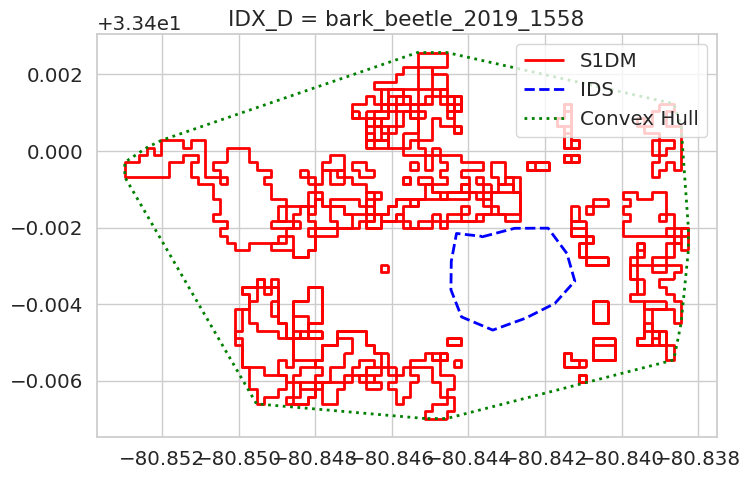

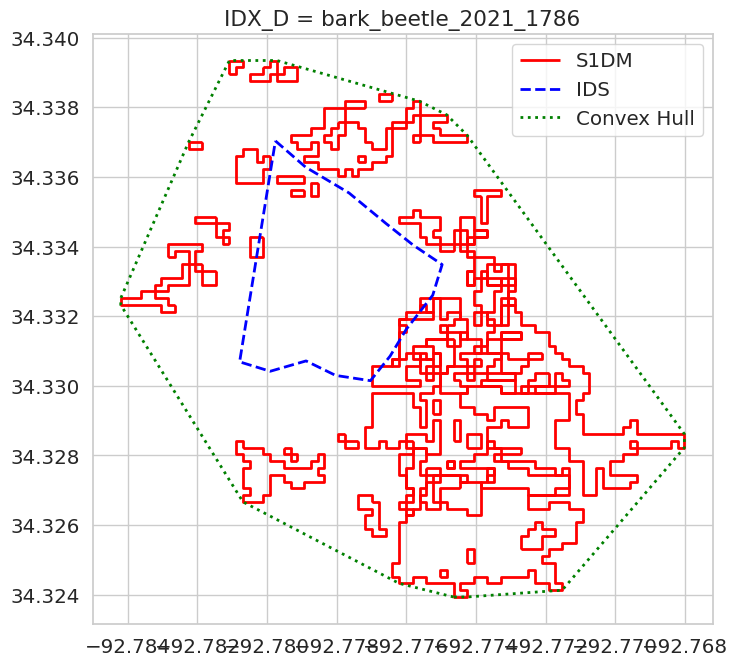

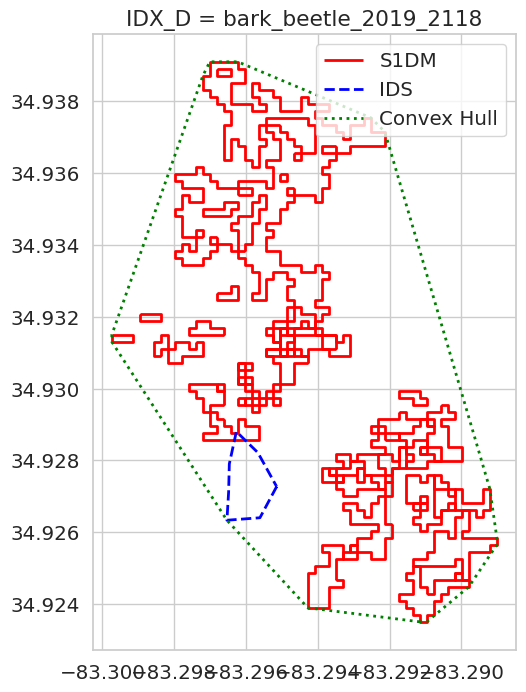

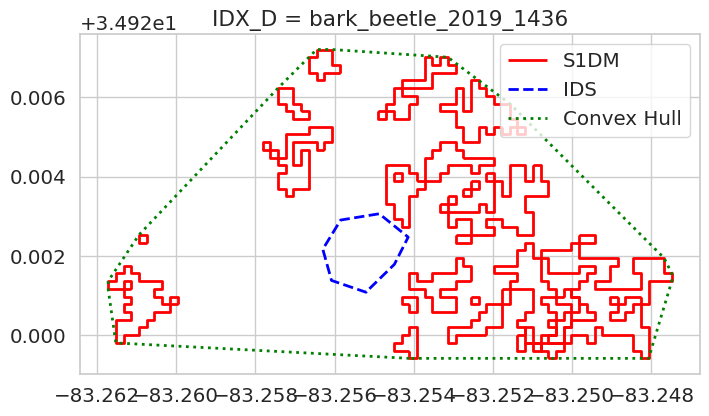

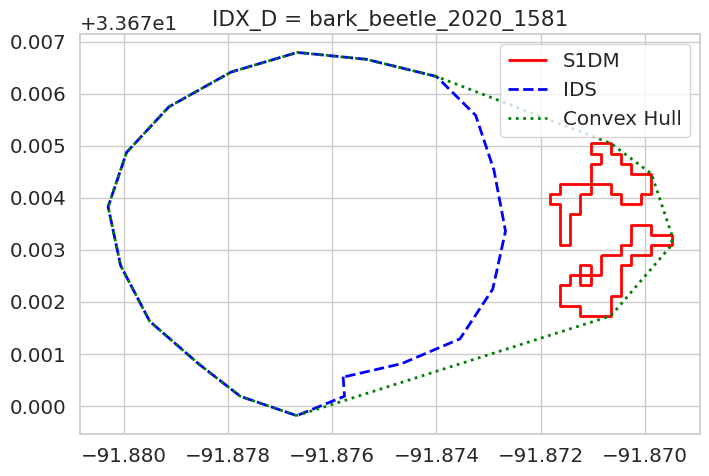

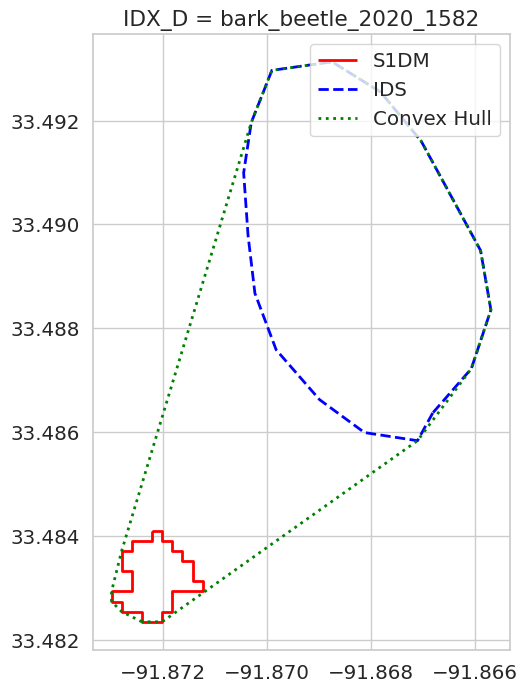

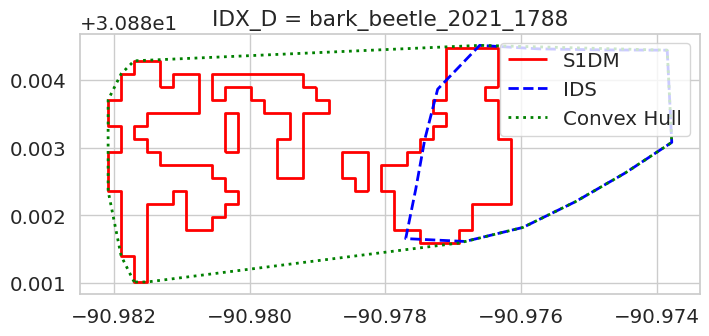

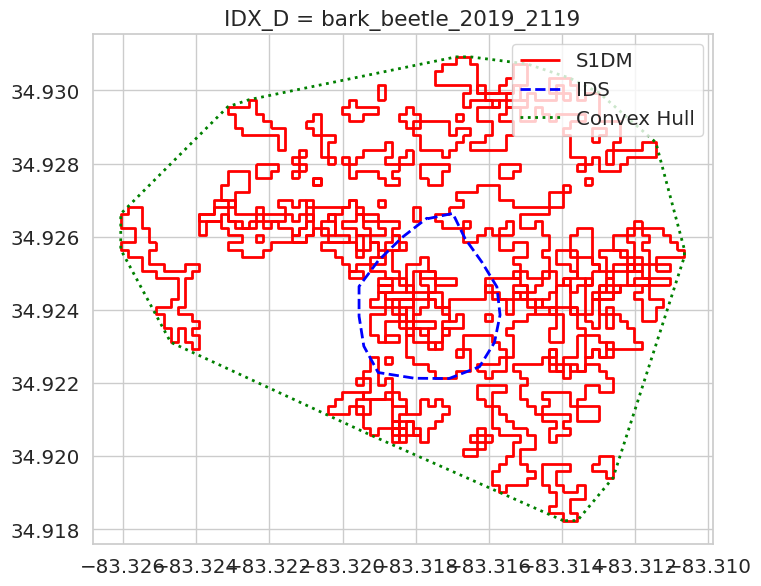

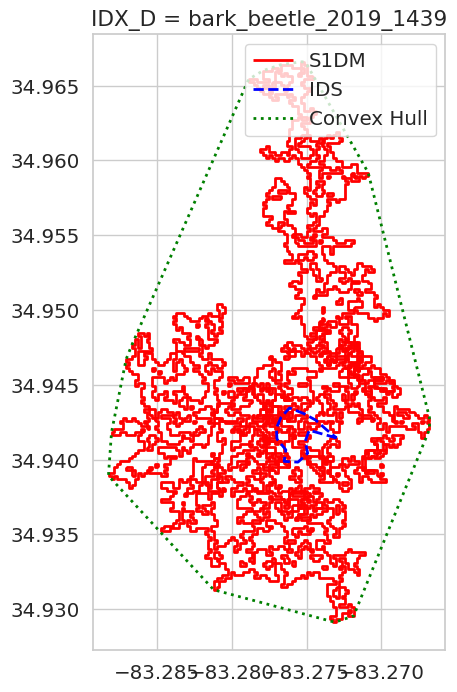

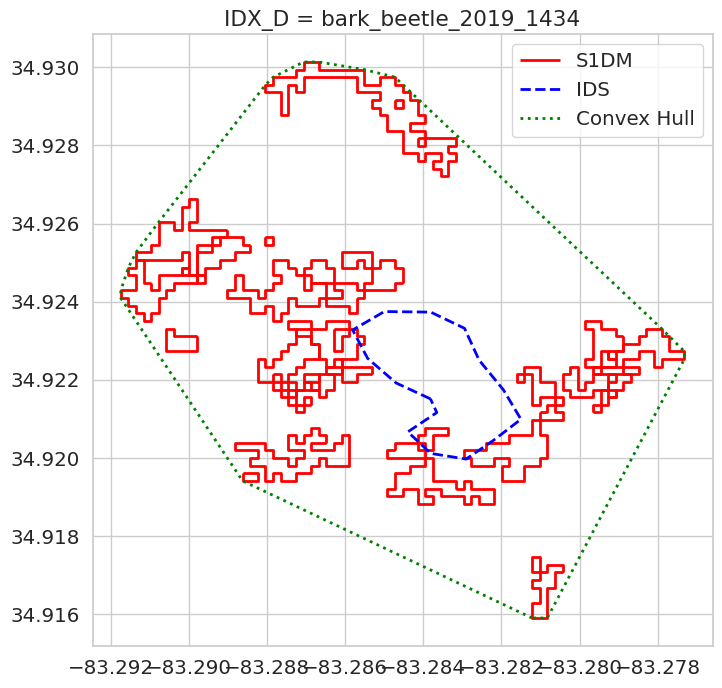

In [36]:
import geopandas as gpd

# Pfade zu den Shapefiles
file_s1dm = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
ids_file = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/region_08_dca_filtered_ids_usda_polygons.shp"

# Laden der Shapefiles
gdf1 = gpd.read_file(file_s1dm)
gdf_ids = gpd.read_file(ids_file)

disturbance = 'bark_beetle'
# Nur Einträge mit DCA_ID == 'defoliators'
gdf2 = gdf1[gdf1['SURVEY_Y'] >= 2019]
gdf_wind = gdf2[gdf2['DCA_ID'] == disturbance]

# Geometrien nach IDX_D zusammenführen
gdf_dissolved = gdf_wind.dissolve(by='IDX_D')

# Zufällig 10 auswählen
gdf_sample = gdf_dissolved.sample(n=10, random_state=356) # 42, 356, 1293, 4321

# Neues GeoDataFrame für die Convex Hulls vorbereiten
convex_list = []

for idx in gdf_sample.index:
    # Wind-Polygone
    wind_geom = gdf_wind[gdf_wind['IDX_D'] == idx]
    # ID-Polygone
    ids_geom = gdf_ids[gdf_ids['IDX_D'] == idx]
    
    # Vereinigung von Wind + IDs
    all_union = None
    if len(wind_geom) > 0 or len(ids_geom) > 0:
        all_union = gpd.GeoSeries(list(wind_geom.geometry) + list(ids_geom.geometry)).union_all()
    
    # Convex Hull
    convex_hull = all_union.convex_hull if all_union else None
    
    if convex_hull:
        convex_list.append({'IDX_D': idx, 'geometry': convex_hull})

# Neues GeoDataFrame erstellen
gdf_convex = gpd.GeoDataFrame(convex_list, crs=gdf_wind.crs)

# Speichern
output_file = f"/net/projects/forexd/WP1/Data/{disturbance}_ids_convex_sample_10_6.shp"
gdf_convex.to_file(output_file)

print(f"10 Convex Hulls gespeichert in: {output_file}")

# Plot für jeden zufälligen IDX_D
for idx in gdf_sample.index:
    # Wind-Polygone
    wind_geom = gdf_wind[gdf_wind['IDX_D'] == idx]
    # ID-Polygone
    ids_geom = gdf_ids[gdf_ids['IDX_D'] == idx]
    
    # Vereinigung von Wind + IDs
    all_union = None
    if len(wind_geom) > 0 or len(ids_geom) > 0:
        all_union = gpd.GeoSeries(list(wind_geom.geometry) + list(ids_geom.geometry)).union_all()
    
    # Convex Hull über die vereinigte Geometrie
    convex_hull = all_union.convex_hull if all_union else None
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Wind-Polygone
    if len(wind_geom) > 0:
        wind_geom.boundary.plot(ax=ax, edgecolor='red', linewidth=2, label='S1DM')
    
    # ID-Polygone
    if len(ids_geom) > 0:
        ids_geom.boundary.plot(ax=ax, edgecolor='blue', linewidth=2, linestyle='--', label='IDS')
    
    # Convex Hull
    if convex_hull:
        gpd.GeoSeries([convex_hull]).boundary.plot(ax=ax, edgecolor='green', linewidth=2, linestyle=':', label='Convex Hull')
    
    plt.title(f"IDX_D = {idx}")
    plt.legend()
    plt.show()


In [42]:
gdf_sample

,geometry,S1_YEAR,S1_TILE,area_left,S1CD_IDX,DCA_ID,SURVEY_Y,REGION_ID,DA_Code_US,ID_E,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,area_right,area
IDX_D,,,,,,,,,,,,,,,,,
defoliators_2021_1722,"MULTIPOLYGON (((-93.43253 32.58555, -93.43253 ...",2020,E084N027T3,0.000566,1722,defoliators,2021,8,2,14586,None,NaN,None,NaN,0.000409,1.443174,0.000566
defoliators_2019_1509,"MULTIPOLYGON (((-91.52379 30.18638, -91.52379 ...",2018,E087N024T3,0.000528,1509,defoliators,2019,8,2,9348,None,NaN,None,NaN,0.016932,4.962489,0.000528
defoliators_2021_1686,"MULTIPOLYGON (((-93.55749 32.61124, -93.5571 3...",2020,E084N027T3,0.001132,1686,defoliators,2021,8,2,14550,None,NaN,None,NaN,0.283429,4.551086,0.001132
defoliators_2021_1761,"MULTIPOLYGON (((-93.60182 32.89745, -93.60182 ...",2021,E084N027T3,0.027833,1761,defoliators,2021,8,2,14662,None,NaN,None,NaN,0.138342,2.908886,0.027833
defoliators_2021_1696,"MULTIPOLYGON (((-93.43057 32.61713, -93.43077 ...",2020,E084N027T3,0.000566,1696,defoliators,2021,8,2,14560,None,NaN,None,NaN,0.187462,1.667222,0.000566
defoliators_2019_2105,"MULTIPOLYGON (((-92.55484 33.94186, -92.55484 ...",2018,E087N027T3,0.049439,2105,defoliators,2019,8,2,8864,8922,2019.0,defoliators,0.0,0.049204,1.447411,0.049439
defoliators_2021_1733,"MULTIPOLYGON (((-93.49119 32.60752, -93.49138 ...",2020,E084N027T3,0.030005,1733,defoliators,2021,8,2,14597,None,NaN,None,NaN,0.258148,2.159211,0.030005
defoliators_2019_1545,"MULTIPOLYGON (((-93.94435 35.82831, -93.94435 ...",2017,E084N030T3,0.000612,1545,defoliators,2019,8,2,9468,None,NaN,None,NaN,0.002443,4.172624,0.000612
defoliators_2019_2103,"MULTIPOLYGON (((-89.70195 30.29536, -89.70195 ...",2018,E090N024T3,0.000524,2103,defoliators,2019,8,2,8848,6858,2018.0,defoliators,-1.0,0.011580,6.530095,0.000524


Union gespeichert als: /net/projects/forexd/WP1/Data/random_manual_sample_files/bark_beetle/bark_beetle_2019_1436/merged_union_multipolygon_bark_beetle_2019_1436.geojson
Plot gespeichert in: /net/projects/forexd/WP1/Figures/manual_disturbances/bark_beetle/plot_bark_beetle_ids_union_bark_beetle_2019_1436.png


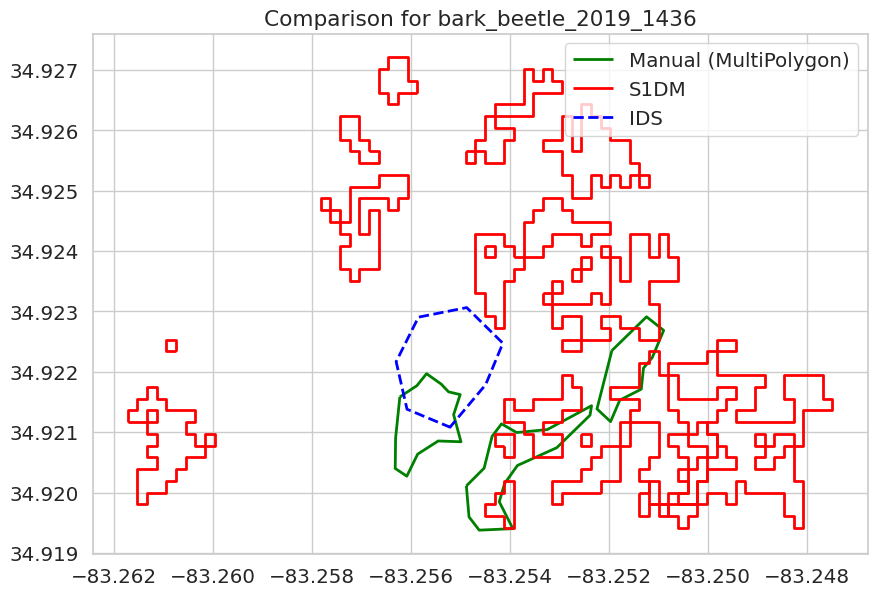

In [38]:
import matplotlib.pyplot as plt
import geopandas as gpd
import geopandas as gpd
import glob
import os

# Beispiel-ID
idx = "bark_beetle_2019_1436"
disturbance = "bark_beetle"

# Ordner mit den GeoJSON-Dateien
folder = f"/net/projects/forexd/WP1/Data/random_manual_sample_files/{disturbance}/{idx}/"

# Alle GeoJSON-Dateien im Ordner finden
files = glob.glob(os.path.join(folder, "*.geojson"))

# Alle Dateien laden und zusammenfügen
gdfs = [gpd.read_file(f) for f in files]
gdf_all = gdfs[0] if len(gdfs) == 1 else gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)


# Alle Geometrien zu einer einzigen MultiPolygon vereinigen
from shapely.validation import make_valid

# Geometrien reparieren
gdf_all["geometry"] = gdf_all.geometry.apply(make_valid)

# Union bilden
union_geom = gdf_all.geometry.union_all()

# In ein GeoDataFrame mit nur einer Zeile packen
gdf_union = gpd.GeoDataFrame([{"geometry": union_geom}], crs=gdf_all.crs)

# Ergebnis speichern (optional)
output_file = os.path.join(folder, f"merged_union_multipolygon_{idx}.geojson")
gdf_union.to_file(output_file, driver="GeoJSON")

print(f"Union gespeichert als: {output_file}")


# Plot vorbereiten
fig, ax = plt.subplots(figsize=(10, 10))

# 1) Union (grün)
gdf_union.boundary.plot(ax=ax, edgecolor="green", linewidth=2, label="Manual (MultiPolygon)")

# 2) Wind-Polygone (rot)
gdf1 = gdf1.set_geometry(gdf1.geometry.buffer(0))
gdf1[gdf1['IDX_D'] == idx].boundary.plot(ax=ax, edgecolor="red", linewidth=2, label="S1DM")

# 3) ID-Polygone (blau)
gdf_ids[gdf_ids['IDX_D'] == idx].boundary.plot(ax=ax, edgecolor="blue", linewidth=2, linestyle="--", label="IDS")

# Legende & Titel
plt.legend()
plt.title(f"Comparison for {idx}")

# Datei speichern
output_plot = f"/net/projects/forexd/WP1/Figures/manual_disturbances/{disturbance}/plot_{disturbance}_ids_union_{idx}.png"
plt.savefig(output_plot, dpi=300, bbox_inches="tight")

print(f"Plot gespeichert in: {output_plot}")
plt.show()


# Compute significance

In [14]:
import os
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import FormatStrFormatter
from shapely.validation import make_valid
from shapely.ops import unary_union
from scipy.stats import ttest_rel



# ==============================================================
# HELPER FUNCTIONS SIMILARITY
# ==============================================================

def compute_overlap_jaccard(geom_candidate, geom_manual):
    """
    Compute Overlap (%) and Jaccard index between candidate and manual geometries.

    Parameters
    ----------
    geom_candidate : shapely.geometry
        Candidate geometry (IDS or S1DM)
    geom_manual : shapely.geometry
        Reference manual geometry

    Returns
    -------
    overlap_pct : float
        Percent of manual area overlapping with candidate
    jaccard : float
        Jaccard index (intersection/union)
    """
    geom_candidate = make_valid(geom_candidate)
    geom_manual = make_valid(geom_manual)

    inter = geom_candidate.intersection(geom_manual)
    union = geom_candidate.union(geom_manual)

    area_inter = inter.area
    area_union = union.area
    area_manual = geom_manual.area

    overlap_pct = (area_inter / area_manual) * 100 if area_manual > 0 else 0
    jaccard = (area_inter / area_union) if area_union > 0 else 0

    return overlap_pct, jaccard


def paired_ttest_significance(x, y, alpha1=0.05, alpha2=0.1, alternative="greater"):
    """
    One-sided paired t-test between S1DM and IDS values.

    Parameters
    ----------
    x, y : array-like
        Sample values (e.g., S1DM vs IDS metrics)
    alpha1 : float
        Primary significance threshold (default=0.05)
    alpha2 : float
        Secondary significance threshold (default=0.1)
    alternative : {"greater","less"}
        One-sided test direction

    Returns
    -------
    pvalue : float
        p-value from paired t-test
    sig_symbol : str
        "*" if p < alpha1, "+" if p < alpha2, else ""
    """
    t_res = ttest_rel(x, y, alternative=alternative)
    if t_res.pvalue < alpha1:
        sig = "*"
    elif t_res.pvalue < alpha2:
        sig = "+"
    else:
        sig = ""
    return t_res.pvalue, sig


In [15]:
from shapely.ops import unary_union
from shapely.validation import make_valid

def get_closest_geom(candidate_gdf, reference_geom, top_n=1):
    """
    Find the closest geometries in candidate_gdf to a reference geometry.

    Parameters
    ----------
    candidate_gdf : GeoDataFrame
        GeoDataFrame with candidate polygons (IDS or S1DM)
    reference_geom : shapely.geometry
        Reference geometry (manual polygon)
    top_n : int, default 1
        Number of closest geometries to return

    Returns
    -------
    GeoSeries
        The top_n closest geometries (merged into a single geometry if multiple)
    """
    candidate_gdf = candidate_gdf.copy()
    candidate_gdf['distance'] = candidate_gdf.geometry.apply(lambda g: reference_geom.distance(g))
    closest = candidate_gdf.nsmallest(top_n, 'distance')
    
    merged_geom = unary_union([make_valid(g) for g in closest.geometry])
    return merged_geom


In [16]:
# ==============================================================
# MAIN PIPELINE
# ==============================================================

def analyze_and_plot_manual_significance(ids_file, s1dm_file, manual_base_folder, out_folder):
    """
    Compute overlap and Jaccard metrics for IDS vs S1DM against manual references,
    run one-sided paired t-tests, and plot results.

    Parameters
    ----------
    ids_file : str
        Path to IDS polygons shapefile
    s1dm_file : str
        Path to S1DM polygons shapefile
    manual_base_folder : str
        Base folder containing manual polygons per disturbance
    out_folder : str
        Output folder for results and figure
    """

    # ---- Load data ----
    gdf_s1dm = gpd.read_file(s1dm_file)
    gdf_ids = gpd.read_file(ids_file)

    disturbances = ['wind', 'bark_beetle', 'defoliators']
    results = []

    # ---- Loop over disturbances ----
    for disturbance in disturbances:
        base_folder = os.path.join(manual_base_folder, disturbance)
        subfolders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]

        for idx in subfolders:
            folder = os.path.join(base_folder, idx)
            manual_file = os.path.join(folder, f"merged_union_multipolygon_{idx}.geojson")
            if not os.path.exists(manual_file):
                continue

            gdf_manual = gpd.read_file(manual_file)
            if gdf_manual.empty:
                continue

            geom_manual = make_valid(gdf_manual.geometry.union_all())
            geom_ids = get_closest_geom(gdf_ids, geom_manual)
            geom_s1dm = get_closest_geom(gdf_s1dm, geom_manual)

            # geom_ids = make_valid(gdf_ids[gdf_ids["IDX_D"] == idx].geometry.union_all())
            # geom_s1dm = make_valid(gdf_s1dm[gdf_s1dm["IDX_D"] == idx].geometry.union_all())

            if geom_ids.is_empty or geom_s1dm.is_empty or geom_manual.is_empty:
                continue

            # Metrics
            overlap_ids, jaccard_ids = compute_overlap_jaccard(geom_ids, geom_manual)
            overlap_s1dm, jaccard_s1dm = compute_overlap_jaccard(geom_s1dm, geom_manual)

            results.append({
                "disturbance": disturbance,
                "idx": idx,
                "overlap_ids": overlap_ids,
                "jaccard_ids": jaccard_ids,
                "overlap_s1dm": overlap_s1dm,
                "jaccard_s1dm": jaccard_s1dm,
            })

    df_results = pd.DataFrame(results)
    os.makedirs(out_folder, exist_ok=True)
    df_results.to_csv(os.path.join(out_folder, "summary_overlap_jaccard.csv"), index=False)

    # ---- Prepare data for plotting ----
    dist_labels = {"wind": "Wind", "bark_beetle": "Bark Beetle", "defoliators": "Defoliators"}
    df_results["disturbance_label"] = df_results["disturbance"].map(dist_labels)

    # Jaccard melt
    df_melt = df_results.melt(
        id_vars=["disturbance_label", "idx"],
        value_vars=["jaccard_ids", "jaccard_s1dm"],
        var_name="method", value_name="jaccard"
    )
    df_melt["method"] = df_melt["method"].map({"jaccard_ids": "IDS", "jaccard_s1dm": "S1DM"})

    # Mean overlap melt
    mean_overlap = df_results.groupby("disturbance_label")[["overlap_ids", "overlap_s1dm"]].mean().reset_index()
    mean_overlap_melt = mean_overlap.melt(
        id_vars="disturbance_label",
        value_vars=["overlap_ids", "overlap_s1dm"],
        var_name="method", value_name="overlap"
    )
    mean_overlap_melt["method"] = mean_overlap_melt["method"].map({"overlap_ids":"IDS","overlap_s1dm":"S1DM"})

    # ---- Compute significance per disturbance ----
    sig_jaccard = {}
    sig_overlap = {}
    for d, group in df_results.groupby("disturbance_label"):
        if len(group) > 1:
            _, sig_j = paired_ttest_significance(group["jaccard_s1dm"], group["jaccard_ids"])
            _, sig_o = paired_ttest_significance(group["overlap_s1dm"], group["overlap_ids"])
            sig_jaccard[d] = sig_j
            sig_overlap[d] = sig_o
        else:
            sig_jaccard[d] = ""
            sig_overlap[d] = ""

   # ==============================================================
    # PLOTTING (Both Panels as Boxplots)
    # ==============================================================

    sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
    palette_custom = {"IDS": "#BCB6FF", "S1DM": "#AF42AE"}
    dist_order_updated = ["Wind", "Bark Beetle", "Defoliators"]

    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)

    # --- a) Jaccard boxplot ---
    ax0 = fig.add_subplot(gs[0])
    sns.boxplot(
        data=df_melt, x="disturbance_label", y="jaccard", hue="method",
        order=dist_order_updated, palette=palette_custom, fliersize=5, linewidth=2.0,
        ax=ax0
    )
    ax0.set_ylabel("Jaccard Similarity", fontsize=22, labelpad=15)
    ax0.set_xlabel("Disturbance Type", fontsize=22, labelpad=12)
    ax0.set_xticklabels(dist_order_updated, fontsize=16)
    ax0.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax0.tick_params(axis='both', labelsize=20)
    ax0.set_ylim(0, 0.55)
    ax0.text(-0.05, 1.05, "a)", transform=ax0.transAxes, fontsize=22, fontweight='bold')

    for i, dist in enumerate(dist_order_updated):
        if sig_jaccard[dist]:
            y_max = df_melt[df_melt["disturbance_label"] == dist]["jaccard"].max()
            ax0.text(i, min(y_max + 0.035, 0.48), sig_jaccard[dist],
                    ha="center", va="bottom", fontsize=30, color="black", fontweight="bold")

    # --- b) Overlap boxplot ---
    ax1 = fig.add_subplot(gs[1])

    # Prepare melted overlap data (same as Jaccard)
    df_overlap_melt = df_results.melt(
        id_vars=["disturbance_label", "idx"],
        value_vars=["overlap_ids", "overlap_s1dm"],
        var_name="method", value_name="overlap"
    )
    df_overlap_melt["method"] = df_overlap_melt["method"].map({"overlap_ids": "IDS", "overlap_s1dm": "S1DM"})

    sns.boxplot(
        data=df_overlap_melt, x="disturbance_label", y="overlap", hue="method",
        order=dist_order_updated, palette=palette_custom, fliersize=5, linewidth=2.0,
        ax=ax1
    )
    ax1.set_ylabel("Overlap (% of Manual Area)", fontsize=22, labelpad=15)
    ax1.set_xlabel("Disturbance Type", fontsize=22, labelpad=12)
    ax1.set_xticklabels(dist_order_updated, fontsize=16)
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax1.tick_params(axis='both', labelsize=20)
    ax1.set_ylim(0,100)
    ax1.text(-0.05, 1.05, "b)", transform=ax1.transAxes, fontsize=22, fontweight='bold')

    for i, dist in enumerate(dist_order_updated):
        if sig_overlap[dist]:
            y_max = df_overlap_melt[df_overlap_melt["disturbance_label"] == dist]["overlap"].max()
            ax1.text(i, min(y_max + 3.0, 48), sig_overlap[dist],
                    ha="center", va="bottom", fontsize=30, color="black", fontweight="bold")

    # --- Combined legend ---
    handles_ds = [
        mpatches.Patch(color=palette_custom['IDS'], label='IDS'),
        mpatches.Patch(color=palette_custom['S1DM'], label='S1DM')
    ]
    star_handle = mlines.Line2D([], [], color='black', marker='*', linestyle='None',
                                markersize=16, label='p < 0.05', markeredgewidth=2)
    plus_handle = mlines.Line2D([], [], color='black', marker='+', linestyle='None',
                                markersize=16, label='p < 0.1', markeredgewidth=2)
    all_handles = handles_ds + [star_handle, plus_handle]
    ax1.legend(handles=all_handles, frameon=True, loc='upper right',
            fontsize=16, handlelength=2.5, handleheight=1.5)
    ax0.get_legend().remove()

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig(os.path.join(out_folder, "jaccard_overlap_boxplots.png"), dpi=300, bbox_inches="tight")
    plt.show()

In [17]:
geom_ids = make_valid(gdf_ids[gdf_ids["IDX_D"] == idx].geometry.union_all())
            # geom_s1dm = make_valid(gdf_s1dm[gdf_s1dm["IDX_D"] == idx].geometry.union_all())

NameError: name 'idx' is not defined

/tmp/ipykernel_2219279/3526906456.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(dist_order_updated, fontsize=16)
/tmp/ipykernel_2219279/3526906456.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(dist_order_updated, fontsize=16)
/tmp/ipykernel_2219279/3526906456.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


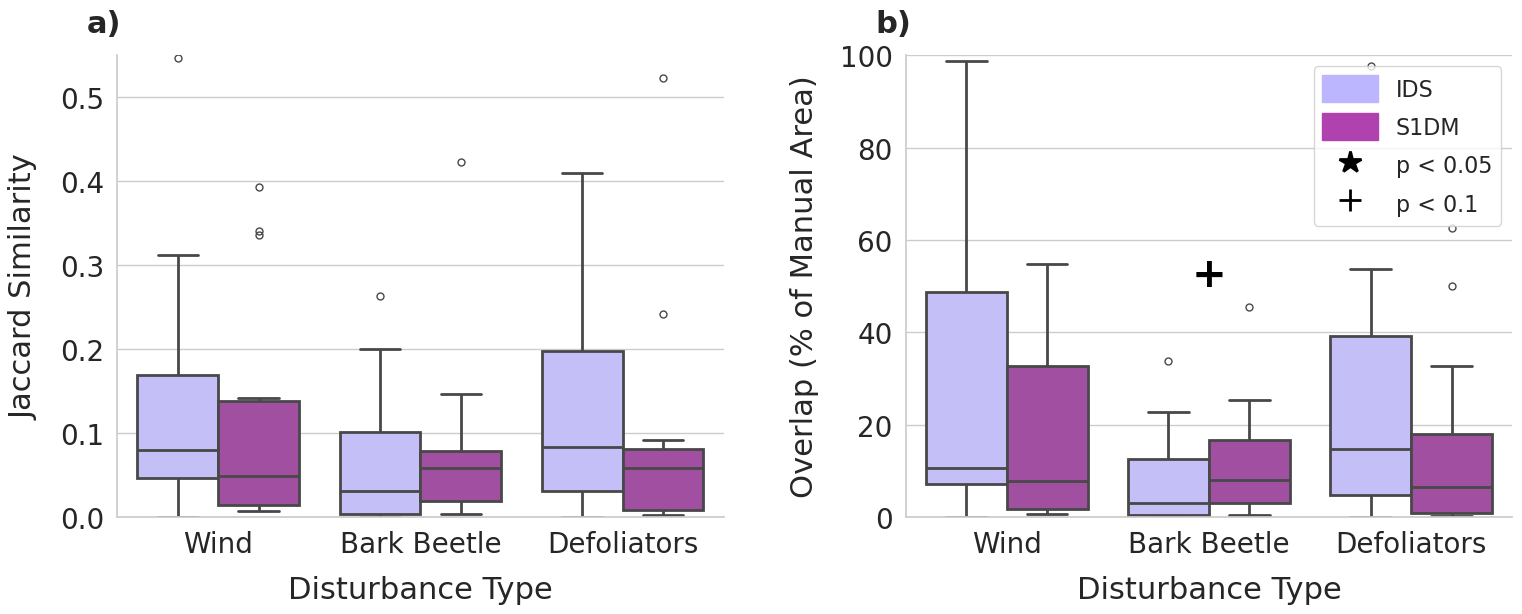

In [ ]:
# Pfade zu den Shapefiles
s1dm_file = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
ids_file = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/region_08_dca_filtered_ids_usda_polygons.shp"
manual_base_folder = "/net/projects/forexd/WP1/Data/random_manual_sample_files/"
out_folder = "/net/projects/forexd/WP1/Figures/manual_disturbances/"

s1dm_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
ids_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region_08_dca_filtered_ids_usda_polygons.shp"

analyze_and_plot_manual_significance(ids_file, s1dm_file, manual_base_folder, out_folder)

# Update the old Manual Idx to new 

In [54]:
import geopandas as gpd
import pandas as pd

# Paths
ids_old = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/region_08_dca_filtered_ids_usda_polygons.shp"
ids_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region_08_dca_filtered_ids_usda_polygons.shp"

# Load shapefiles
gdf_old = gpd.read_file(ids_old)
gdf_new = gpd.read_file(ids_new)

# Drop fire and drought
exclude = ["fire", "drought"]
gdf_old = gdf_old[~gdf_old["DCA_ID"].isin(exclude)].reset_index(drop=True)
gdf_new = gdf_new[~gdf_new["DCA_ID"].isin(exclude)].reset_index(drop=True)

# Ensure same CRS
if gdf_old.crs != gdf_new.crs:
    gdf_new = gdf_new.to_crs(gdf_old.crs)

# Add WKB (Well-Known-Binary) representation to compare geometries exactly
gdf_old["geom_wkb"] = gdf_old.geometry.apply(lambda g: g.wkb if g else None)
gdf_new["geom_wkb"] = gdf_new.geometry.apply(lambda g: g.wkb if g else None)

# Merge on geometry + disturbance type
merged = pd.merge(
    gdf_old[["IDX_D", "DCA_ID", "geom_wkb"]],
    gdf_new[["IDX_D", "DCA_ID", "geom_wkb"]],
    on=["DCA_ID", "geom_wkb"],
    how="outer",
    suffixes=("_old", "_new")
)

# 1. Perfect matches (same DCA_ID and exactly same geometry)
exact_matches = merged.dropna(subset=["IDX_D_old", "IDX_D_new"])

# 2. Old geometries with no match in new
only_in_old = merged[merged["IDX_D_new"].isna()]

# 3. New geometries with no match in old
only_in_new = merged[merged["IDX_D_old"].isna()]

print(f"Total old geometries (after filtering): {len(gdf_old)}")
print(f"Total new geometries (after filtering): {len(gdf_new)}")
print(f"Exact matches: {len(exact_matches)}")
print(f"Only in old: {len(only_in_old)}")
print(f"Only in new: {len(only_in_new)}")

# Optional: show counts per DCA_ID
per_type = pd.DataFrame({
    "exact_matches": exact_matches.groupby("DCA_ID").size(),
    "only_in_old": only_in_old.groupby("DCA_ID").size(),
    "only_in_new": only_in_new.groupby("DCA_ID").size()
}).fillna(0).astype(int)

print("\nBreakdown per DCA_ID (excluding fire/drought):")
print(per_type)


Total old geometries (after filtering): 2001
Total new geometries (after filtering): 1868
Exact matches: 1878
Only in old: 133
Only in new: 0

Breakdown per DCA_ID (excluding fire/drought):
             exact_matches  only_in_old  only_in_new
DCA_ID                                              
bark_beetle           1177            9            0
defoliators            221           94            0
wind                   480           30            0


In [55]:
import os
import pandas as pd

manual_base_folder = "/net/projects/forexd/WP1/Data/random_manual_sample_files/"
disturbances = ['wind', 'bark_beetle', 'defoliators']

rows = []

for disturbance in disturbances:
    base_folder = os.path.join(manual_base_folder, disturbance)
    if not os.path.exists(base_folder):
        continue

    subfolders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]
    for foldername in subfolders:
        rows.append({
            "disturbance": disturbance,
            "manual_idx": foldername
        })

df_folders = pd.DataFrame(rows)
df_folders


,disturbance,manual_idx
0,wind,wind_2018_1392
1,wind,wind_2019_2044
2,wind,wind_2019_1988
3,wind,wind_2018_1872
4,wind,wind_2019_2011
5,wind,wind_2018_1930
6,wind,wind_2019_2061
7,wind,wind_2019_2037
8,wind,wind_2019_1430
9,wind,wind_2019_1496


In [56]:
# Set für schnellen Vergleich
exact_set = set(exact_matches['IDX_D_old'])

# Prüfen, ob manual_idx in exact_matches['IDX_D_old'] enthalten ist
df_folders['in_exact_matches'] = df_folders['manual_idx'].apply(lambda x: x in exact_set)

# Zählen
num_in_matches = df_folders['in_exact_matches'].sum()
num_not_in_matches = (~df_folders['in_exact_matches']).sum()

print(f"Number of manual_idx in exact_matches: {num_in_matches}")
print(f"Number of manual_idx NOT in exact_matches: {num_not_in_matches}")

# Mapping old -> new
old_to_new_map = dict(zip(exact_matches['IDX_D_old'], exact_matches['IDX_D_new']))

# Neue Spalte nur für die manual_idx, die in exact_matches sind
df_folders['IDX_D_new'] = df_folders['manual_idx'].apply(lambda x: old_to_new_map[x] if x in exact_set else None)

# Ergebnis prüfen
df_folders


Number of manual_idx in exact_matches: 43
Number of manual_idx NOT in exact_matches: 10


,disturbance,manual_idx,in_exact_matches,IDX_D_new
0,wind,wind_2018_1392,True,wind_2018_1392
1,wind,wind_2019_2044,True,wind_2019_1929
2,wind,wind_2019_1988,True,wind_2019_1873
3,wind,wind_2018_1872,True,wind_2018_1757
4,wind,wind_2019_2011,True,wind_2019_1896
5,wind,wind_2018_1930,True,wind_2018_1815
6,wind,wind_2019_2061,True,wind_2019_1946
7,wind,wind_2019_2037,True,wind_2019_1922
8,wind,wind_2019_1430,True,wind_2019_1430
9,wind,wind_2019_1496,True,wind_2019_1496


In [51]:
import geopandas as gpd
import os
import pandas as pd
from shapely.ops import unary_union

# Path to the folder containing the .geojson files
folder_path = "/net/projects/forexd/WP1/Data/random_manual_sample_files/bark_beetle/bark_beetle_2019_1432"

# Loop over all files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".geojson"):
        manual_idx = os.path.splitext(filename)[0]  # filename without extension

        # Read all GeoJSONs in the folder
        geojson_files = [f for f in os.listdir(folder_path) if f.endswith(".geojson")]
        gdfs = [gpd.read_file(os.path.join(folder_path, f)) for f in geojson_files]

        # Merge all into one GeoDataFrame
        merged_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

        # Union all geometries
        merged_union = merged_gdf.union_all()
        result_gdf = gpd.GeoDataFrame(geometry=[merged_union], crs=merged_gdf.crs)

        # Save to new file with the dynamic name
        output_path = os.path.join(folder_path, f"merged_union_multipolygon_{manual_idx}.geojson")
        result_gdf.to_file(output_path, driver="GeoJSON")

        print(f"Merged file created: {output_path}")
        break  # just use the first filename for naming


Merged file created: /net/projects/forexd/WP1/Data/random_manual_sample_files/bark_beetle/bark_beetle_2019_1432/merged_union_multipolygon_bark_beetle_2019_1432_4.geojson


In [42]:
from shapely.validation import make_valid

def analyze_and_plot_manual_significance(ids_file, s1dm_file, manual_base_folder, result_path, save_path, manual_to_new_map):
    """
    Compute overlap and Jaccard metrics for IDS vs S1DM against manual references,
    using the NEW IDX_D selected from manual folders.
    """

    # ---- Load data ----
    gdf_s1dm = gpd.read_file(s1dm_file)
    gdf_ids = gpd.read_file(ids_file)

    disturbances = ['wind', 'bark_beetle', 'defoliators']
    results = []
    skipped_entries = {
        "no_mapping": [],
        "no_file": [],
        "empty_manual": [],
        "empty_geoms": [],
        "filtered_out": []
    }

    # ---- Loop over disturbances ----
    for disturbance in disturbances:
        base_folder = os.path.join(manual_base_folder, disturbance)
        subfolders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]

        for manual_idx in subfolders:
            print(manual_idx)
            folder = os.path.join(base_folder, manual_idx)
            manual_file = os.path.join(folder, f"merged_union_multipolygon_{manual_idx}.geojson")

            if not os.path.exists(manual_file):
                skipped_entries["no_file"].append(manual_idx)
                continue

            gdf_manual = gpd.read_file(manual_file)
            if gdf_manual.empty:
                skipped_entries["empty_manual"].append(manual_idx)
                continue

            geom_manual = make_valid(gdf_manual.geometry.union_all())

            # ---- USE NEW IDX_D INSTEAD OF OLD ----
            row = manual_to_new_map[manual_to_new_map['manual_idx'] == manual_idx]
            if row.empty:
                skipped_entries["no_mapping"].append(manual_idx)
                continue  # skip if mapping not found

            new_idx = row['IDX_D_new'].values[0]  # get the scalar value

            new_idx = row['IDX_D_new'].values[0]  # get the scalar value

            # Handle _current entries
            if "_current" in manual_idx:
                # Use the same ID but without '_current' for IDS/S1DM lookups
                new_idx = manual_idx.replace("_current", "")
                    

            geom_ids = make_valid(gdf_ids[gdf_ids["IDX_D"] == new_idx].geometry.union_all())
            geom_s1dm = make_valid(gdf_s1dm[gdf_s1dm["IDX_D"] == new_idx].geometry.union_all())

            if geom_ids.is_empty or geom_s1dm.is_empty or geom_manual.is_empty:
                skipped_entries["empty_geoms"].append(manual_idx)
                continue

            # Metrics
            overlap_ids, jaccard_ids = compute_overlap_jaccard(geom_ids, geom_manual)
            overlap_s1dm, jaccard_s1dm = compute_overlap_jaccard(geom_s1dm, geom_manual)

            results.append({
                "disturbance": disturbance,
                "manual_idx": manual_idx,
                "new_idx": new_idx,
                "overlap_ids": overlap_ids,
                "jaccard_ids": jaccard_ids,
                "overlap_s1dm": overlap_s1dm,
                "jaccard_s1dm": jaccard_s1dm,
            })

    # ---- Save results ----
    df_results = pd.DataFrame(results)
    # ---- Compute median values for reporting ----
    median_values = {}
    for disturbance in ['wind', 'bark_beetle', 'defoliators']:
        df_sub = df_results[df_results['disturbance'] == disturbance]
        median_jaccard_s1dm = df_sub['jaccard_s1dm'].median()
        median_jaccard_ids = df_sub['jaccard_ids'].median()
        median_overlap_s1dm = df_sub['overlap_s1dm'].median()
        median_overlap_ids = df_sub['overlap_ids'].median()
        
        median_values[disturbance] = {
            "jaccard_s1dm": median_jaccard_s1dm,
            "jaccard_ids": median_jaccard_ids,
            "overlap_s1dm": median_overlap_s1dm,
            "overlap_ids": median_overlap_ids
        }

    # ---- Print the values neatly ----
    print("\n=== Median Metrics per Disturbance ===")
    for disturbance, metrics in median_values.items():
        print(f"\n{disturbance.capitalize()}:")
        print(f"  Jaccard - S1DM: {metrics['jaccard_s1dm']:.3f}, IDS: {metrics['jaccard_ids']:.3f}")
        print(f"  Overlap (%) - S1DM: {metrics['overlap_s1dm']:.1f}, IDS: {metrics['overlap_ids']:.1f}")
    print("====================================\n")

    # ---- Print summary counts ----
    counts = df_results["disturbance"].value_counts().reindex(["wind", "bark_beetle", "defoliators"], fill_value=0)
    print("\n=== Processed Manual Entries per Disturbance ===")
    for d, n in counts.items():
        print(f"{d.capitalize():<15}: {n} entries calculated")
    print("===============================================\n")

    # ---- Print skipped summary ----
    print("\n=== Skipped Entries Summary ===")
    for reason, items in skipped_entries.items():
        print(f"\n{reason.replace('_', ' ').capitalize()} ({len(items)}):")
        for idx in items:
            print(f"  - {idx}")
    print("================================\n")

    # ==============================================================
    # PLOTTING (Both Panels as Boxplots)
    # ==============================================================

    #os.makedirs(result_path, exist_ok=True)
    #df_results.to_csv(os.path.join(result_path, "summary_overlap_jaccard.csv"), index=False)

    dist_labels = {"wind": "Wind", "bark_beetle": "Bark Beetle", "defoliators": "Defoliators"}
    df_results["disturbance_label"] = df_results["disturbance"].map(dist_labels)

    # Jaccard melt
    df_melt = df_results.melt(
        id_vars=["disturbance_label", "new_idx"],
        value_vars=["jaccard_ids", "jaccard_s1dm"],
        var_name="method", value_name="jaccard"
    )
    df_melt["method"] = df_melt["method"].map({"jaccard_ids": "IDS", "jaccard_s1dm": "S1DM"})

    # Mean overlap melt
    mean_overlap = df_results.groupby("disturbance_label")[["overlap_ids", "overlap_s1dm"]].mean().reset_index()
    mean_overlap_melt = mean_overlap.melt(
        id_vars="disturbance_label",
        value_vars=["overlap_ids", "overlap_s1dm"],
        var_name="method", value_name="overlap"
    )
    mean_overlap_melt["method"] = mean_overlap_melt["method"].map({"overlap_ids": "IDS", "overlap_s1dm": "S1DM"})

    # ---- Compute significance per disturbance ----
    sig_jaccard = {}
    sig_overlap = {}
    for d, group in df_results.groupby("disturbance_label"):
        if len(group) > 1:
            _, sig_j = paired_ttest_significance(group["jaccard_s1dm"], group["jaccard_ids"])
            _, sig_o = paired_ttest_significance(group["overlap_s1dm"], group["overlap_ids"])
            sig_jaccard[d] = sig_j
            sig_overlap[d] = sig_o
        else:
            sig_jaccard[d] = ""
            sig_overlap[d] = ""

    # ==============================================================
    # PLOTTING
    # ==============================================================

    sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
    palette_custom = {"IDS": "#BCB6FF", "S1DM": "#AF42AE"}
    dist_order_updated = ["Wind", "Bark Beetle", "Defoliators"]

    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)

    # --- a) Jaccard boxplot ---
    ax0 = fig.add_subplot(gs[0])
    sns.boxplot(
        data=df_melt, x="disturbance_label", y="jaccard", hue="method",
        order=dist_order_updated, palette=palette_custom, fliersize=5, linewidth=2.0,
        ax=ax0
    )
    ax0.set_ylabel("Jaccard Similarity", fontsize=22, labelpad=15)
    ax0.set_xlabel("Disturbance Type", fontsize=22, labelpad=12)
    ax0.set_xticklabels(dist_order_updated, fontsize=16)
    ax0.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax0.tick_params(axis='both', labelsize=20)
    ax0.set_ylim(-0.01, 0.55)
    ax0.text(-0.05, 1.05, "a)", transform=ax0.transAxes, fontsize=22, fontweight='bold')

    for i, dist in enumerate(dist_order_updated):
        if sig_jaccard[dist]:
            y_max = df_melt[df_melt["disturbance_label"] == dist]["jaccard"].max()
            ax0.text(i, min(y_max + 0.035, 0.48), sig_jaccard[dist],
                    ha="center", va="bottom", fontsize=30, color="black", fontweight="bold")

    # --- b) Overlap boxplot ---
    ax1 = fig.add_subplot(gs[1])

    df_overlap_melt = df_results.melt(
        id_vars=["disturbance_label", "new_idx"],
        value_vars=["overlap_ids", "overlap_s1dm"],
        var_name="method", value_name="overlap"
    )
    df_overlap_melt["method"] = df_overlap_melt["method"].map({"overlap_ids": "IDS", "overlap_s1dm": "S1DM"})

    sns.boxplot(
        data=df_overlap_melt, x="disturbance_label", y="overlap", hue="method",
        order=dist_order_updated, palette=palette_custom, fliersize=5, linewidth=2.0,
        ax=ax1
    )
    ax1.set_ylabel("Overlap (% of Manual Area)", fontsize=22, labelpad=15)
    ax1.set_xlabel("Disturbance Type", fontsize=22, labelpad=12)
    ax1.set_xticklabels(dist_order_updated, fontsize=16)
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax1.tick_params(axis='both', labelsize=20)
    ax1.set_ylim(-1, 105)
    ax1.text(-0.05, 1.05, "b)", transform=ax1.transAxes, fontsize=22, fontweight='bold')

    for i, dist in enumerate(dist_order_updated):
        if sig_overlap[dist]:
            y_max = df_overlap_melt[df_overlap_melt["disturbance_label"] == dist]["overlap"].max()
            ax1.text(i, min(y_max + 5.0, 90), sig_overlap[dist],
                    ha="center", va="bottom", fontsize=30, color="black", fontweight="bold")

    handles_ds = [
        mpatches.Patch(color=palette_custom['IDS'], label='IDS'),
        mpatches.Patch(color=palette_custom['S1DM'], label='S1DM')
    ]
    star_handle = mlines.Line2D([], [], color='black', marker='*', linestyle='None',
                                markersize=16, label='p < 0.05', markeredgewidth=2)
    plus_handle = mlines.Line2D([], [], color='black', marker='+', linestyle='None',
                                markersize=16, label='p < 0.1', markeredgewidth=2)
    all_handles = handles_ds + [star_handle, plus_handle]
    ax1.legend(handles=all_handles, frameon=True, loc='upper right',
            fontsize=16, handlelength=2.5, handleheight=1.5,facecolor='white')
    ax0.get_legend().remove()

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    if save_path:
        plt.savefig(save_path, dpi=400, bbox_inches="tight")
    plt.show()


/tmp/ipykernel_2468096/4154516441.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_manual = make_valid(gdf_manual.geometry.unary_union)
/tmp/ipykernel_2468096/4154516441.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_ids = make_valid(gdf_ids[gdf_ids["IDX_D"] == manual_idx].geometry.unary_union)
/tmp/ipykernel_2468096/4154516441.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_s1dm = make_valid(gdf_s1dm[gdf_s1dm["IDX_D"] == manual_idx].geometry.unary_union)
/tmp/ipykernel_2468096/4154516441.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_2468096/4154516441.py:38: UserWarning: No artists with labels found to put in le

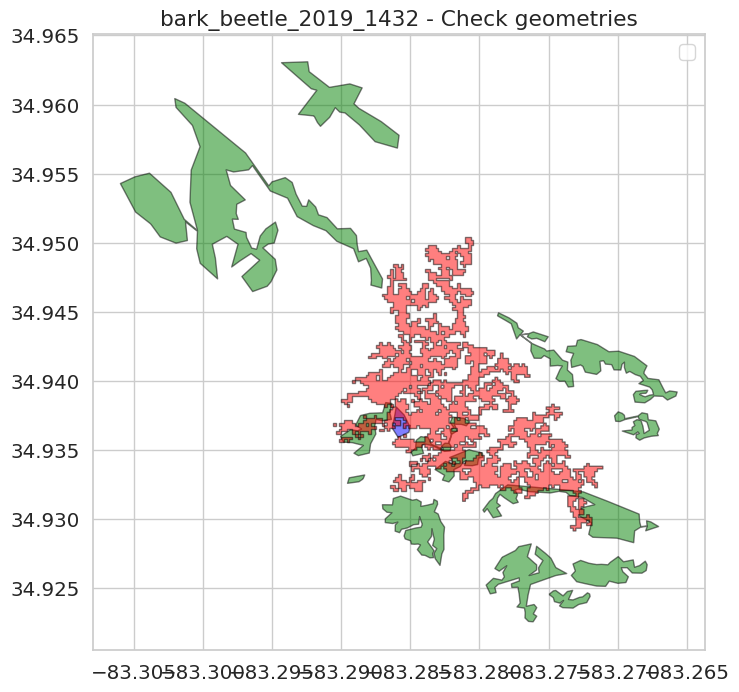

In [57]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.validation import make_valid

manual_idx = "bark_beetle_2019_1432"
manual_file = f"{manual_base_folder}/bark_beetle/{manual_idx}/merged_union_multipolygon_{manual_idx}.geojson"

ids_file = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region_08_dca_filtered_ids_usda_polygons.shp"
s1dm_file = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
gdf_s1dm = gpd.read_file(s1dm_file)
gdf_ids = gpd.read_file(ids_file)

# Load manual polygons
gdf_manual = gpd.read_file(manual_file)
geom_manual = make_valid(gdf_manual.geometry.unary_union)

# Determine new_idx
row = df_folders[df_folders['manual_idx'] == manual_idx]
if not row.empty:
    new_idx = row['IDX_D_new'].values[0]
else:
    new_idx = None

# Load IDS and S1DM polygons for this IDX
geom_ids = make_valid(gdf_ids[gdf_ids["IDX_D"] == manual_idx].geometry.unary_union)
geom_s1dm = make_valid(gdf_s1dm[gdf_s1dm["IDX_D"] == manual_idx].geometry.unary_union)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
if not geom_manual.is_empty:
    gpd.GeoSeries([geom_manual]).plot(ax=ax, color='green', alpha=0.5, edgecolor='black', label='Manual')
if not geom_ids.is_empty:
    gpd.GeoSeries([geom_ids]).plot(ax=ax, color='blue', alpha=0.5, edgecolor='black', label='IDS')
if not geom_s1dm.is_empty:
    gpd.GeoSeries([geom_s1dm]).plot(ax=ax, color='red', alpha=0.5, edgecolor='black', label='S1DM')

ax.set_title(f"{manual_idx} - Check geometries")
ax.legend()
plt.show()


wind_2018_1392
wind_2019_2044
wind_2019_1988
wind_2018_1872
wind_2019_2011
wind_2018_1930
wind_2019_2061
wind_2019_2037
wind_2019_1430
wind_2019_1496
wind_2018_1913
wind_2018_1919
wind_2018_1917
wind_2020_2045_current
wind_2018_1879
wind_2018_1903
bark_beetle_2018_884
bark_beetle_2017_84
bark_beetle_2018_454
bark_beetle_2018_1136
bark_beetle_2017_41
bark_beetle_2017_22
bark_beetle_2018_496
bark_beetle_2019_1434
bark_beetle_2018_938
bark_beetle_2018_975
bark_beetle_2019_1434_current
bark_beetle_2019_1559_current
bark_beetle_2018_1039
bark_beetle_2018_1020
bark_beetle_2018_886
defoliators_2018_275
defoliators_2017_95
defoliators_2019_1536_current
defoliators_2018_265
defoliators_2018_1827
defoliators_2017_75
defoliators_2019_1418_current
defoliators_2018_262
defoliators_2019_2112
defoliators_2019_1403
defoliators_2019_2131
defoliators_2021_1692
defoliators_2021_1771
defoliators_2017_1815
defoliators_2021_1730
defoliators_2018_313
defoliators_2019_2009_current
defoliators_2017_1812

=== M

/tmp/ipykernel_2292102/2661230104.py:182: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(dist_order_updated, fontsize=16)
/tmp/ipykernel_2292102/2661230104.py:211: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(dist_order_updated, fontsize=16)
/tmp/ipykernel_2292102/2661230104.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


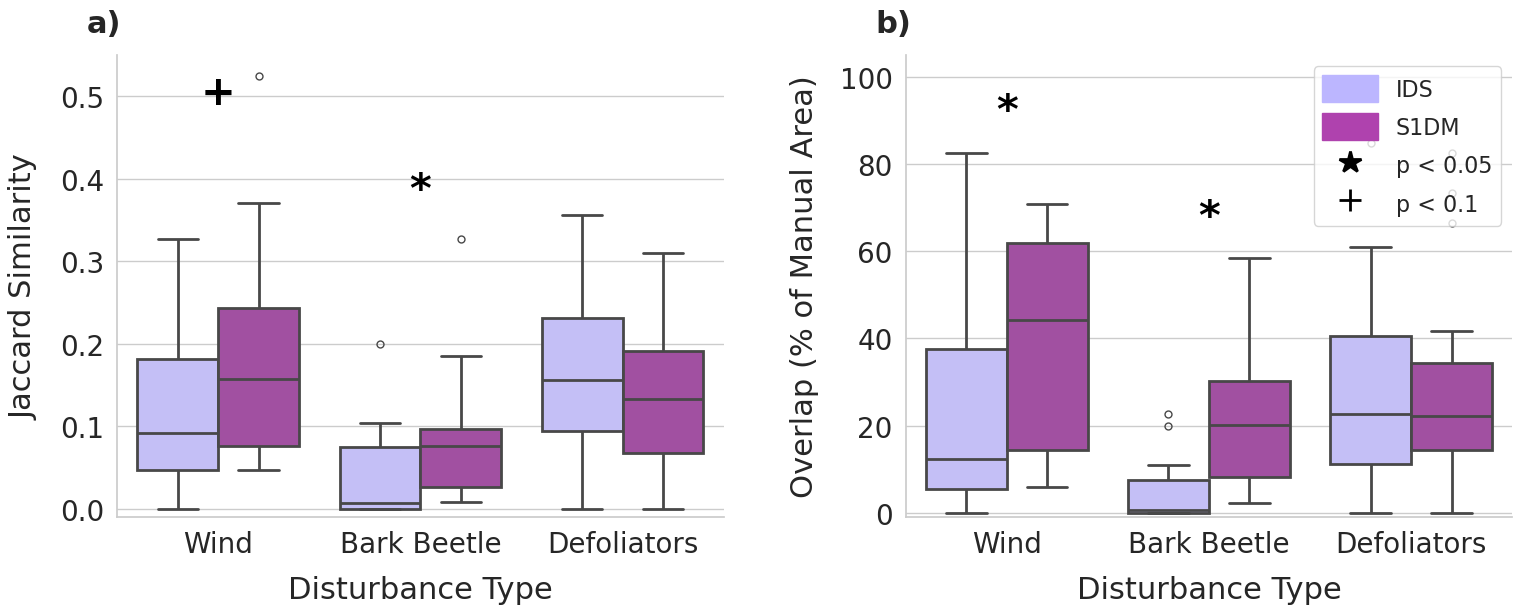

In [104]:
ids_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region_08_dca_filtered_ids_usda_polygons.shp"
ids_old = "/net/projects/forexd/WP1/03_LearningDisturbances/Data/region_08_dca_filtered_ids_usda_polygons.shp"
s1dm_new = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
analyze_and_plot_manual_significance(ids_new, 
                                    s1dm_new, 
                                    manual_base_folder, 
                                    '/',
                                    '/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/figures/F08_p1_f7_significance_manual.png',
                                    df_folders
                                    )

# Rename the indexes

In [6]:
import os
import pandas as pd

# Assuming `exact_matches` DataFrame has: ['IDX_D_old', 'IDX_D_new']
manual_base_folder = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels"

# Create mapping
old_to_new_map = dict(zip(exact_matches['IDX_D_old'], exact_matches['IDX_D_new']))

# Disturbance types
disturbances = ['wind', 'bark_beetle', 'defoliators']

# Optional: keep track of unmapped or skipped folders
unmapped = []
renamed = []

for disturbance in disturbances:
    base_path = os.path.join(manual_base_folder, disturbance)
    if not os.path.exists(base_path):
        print(f"⚠️ Skipping missing folder: {base_path}")
        continue

    for old_folder in os.listdir(base_path):
        old_path = os.path.join(base_path, old_folder)
        if not os.path.isdir(old_path):
            continue

        # Get new name
        new_name = old_to_new_map.get(old_folder)

        # Skip if no mapping or invalid
        if not new_name or pd.isna(new_name):
            print(f"⚠️ Skipping {old_folder} – no valid new_idx found.")
            unmapped.append({"disturbance": disturbance, "old_folder": old_folder})
            continue

        new_path = os.path.join(base_path, new_name)

        # --- Rename folder ---
        if not os.path.exists(new_path):
            os.rename(old_path, new_path)
            print(f"📁 Renamed folder: {old_folder} → {new_name}")
        else:
            print(f"⚠️ Target folder already exists: {new_path}")

        # --- Rename file inside ---
        old_file = os.path.join(new_path, f"merged_union_multipolygon_{old_folder}.geojson")
        new_file = os.path.join(new_path, f"merged_union_multipolygon_{new_name}.geojson")

        if os.path.exists(old_file):
            os.rename(old_file, new_file)
            print(f"📄 Renamed file: {old_file} → {new_file}")
            renamed.append({"disturbance": disturbance, "old": old_folder, "new": new_name})
        else:
            print(f"⚠️ File not found: {old_file}")


📁 Renamed folder: wind_2018_1872 → wind_2018_1757
⚠️ File not found: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels/wind/wind_2018_1757/merged_union_multipolygon_wind_2018_1872.geojson
📁 Renamed folder: wind_2019_2011 → wind_2019_1896
📄 Renamed file: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels/wind/wind_2019_1896/merged_union_multipolygon_wind_2019_2011.geojson → /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels/wind/wind_2019_1896/merged_union_multipolygon_wind_2019_1896.geojson
📁 Renamed folder: wind_2018_1930 → wind_2018_1815
📄 Renamed file: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels/wind/wind_2018_1815/merged_union_multipolygon_wind_2018_1930.geojson → /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels/wind/wind_2018_1815/merged_union_multipolygon_wind_2018_1815.geo

In [59]:
import os
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import FormatStrFormatter
from shapely.validation import make_valid
from scipy.stats import ttest_rel


# ==============================================================
# HELPER FUNCTIONS
# ==============================================================

def compute_overlap_jaccard(geom_candidate, geom_manual):
    """Compute Overlap (%) and Jaccard index between candidate and manual geometries."""
    geom_candidate = make_valid(geom_candidate)
    geom_manual = make_valid(geom_manual)

    inter = geom_candidate.intersection(geom_manual)
    union = geom_candidate.union(geom_manual)

    area_inter = inter.area
    area_union = union.area
    area_manual = geom_manual.area

    overlap_pct = (area_inter / area_manual) * 100 if area_manual > 0 else 0
    jaccard = (area_inter / area_union) if area_union > 0 else 0
    return overlap_pct, jaccard


def paired_ttest_significance(x, y, alpha1=0.05, alpha2=0.1, alternative="greater"):
    """One-sided paired t-test; returns significance symbol."""
    t_res = ttest_rel(x, y, alternative=alternative)
    if t_res.pvalue < alpha1:
        return t_res.pvalue, "*"
    elif t_res.pvalue < alpha2:
        return t_res.pvalue, "+"
    return t_res.pvalue, ""


# ==============================================================
# MAIN ANALYSIS FUNCTION
# ==============================================================

def analyze_and_plot_manual_significance(ids_file, s1dm_file, manual_base_folder, result_path=None, save_path=None):
    """
    Compute overlap and Jaccard metrics for IDS vs S1DM against manual references.
    Uses actual folder/file names (already renamed to new IDX_D).
    """
    gdf_s1dm = gpd.read_file(s1dm_file)
    gdf_ids = gpd.read_file(ids_file)

    disturbances = ['wind', 'bark_beetle', 'defoliators']
    results = []
    skipped_entries = {"no_file": [], "empty_manual": [], "empty_geoms": []}

    # ---- Loop over disturbances ----
    for disturbance in disturbances:
        base_folder = os.path.join(manual_base_folder, disturbance)
        subfolders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]

        for idx_name in subfolders:
            #print(idx_name)
            manual_file = os.path.join(base_folder, idx_name, f"merged_union_multipolygon_{idx_name}.geojson")

            if not os.path.exists(manual_file):
                skipped_entries["no_file"].append(idx_name)
                continue

            gdf_manual = gpd.read_file(manual_file)
            if gdf_manual.empty:
                skipped_entries["empty_manual"].append(idx_name)
                continue

            geom_manual = make_valid(gdf_manual.geometry.union_all())
            geom_ids = make_valid(gdf_ids[gdf_ids["IDX_D"] == idx_name].geometry.union_all())
            geom_s1dm = make_valid(gdf_s1dm[gdf_s1dm["IDX_D"] == idx_name].geometry.union_all())

            if geom_ids.is_empty or geom_s1dm.is_empty or geom_manual.is_empty:
                skipped_entries["empty_geoms"].append(idx_name)
                continue

            overlap_ids, jaccard_ids = compute_overlap_jaccard(geom_ids, geom_manual)
            overlap_s1dm, jaccard_s1dm = compute_overlap_jaccard(geom_s1dm, geom_manual)

            results.append({
                "disturbance": disturbance,
                "idx": idx_name,
                "overlap_ids": overlap_ids,
                "jaccard_ids": jaccard_ids,
                "overlap_s1dm": overlap_s1dm,
                "jaccard_s1dm": jaccard_s1dm,
            })

    # ---- Convert to DataFrame ----
    df_results = pd.DataFrame(results)
    dist_labels = {"wind": "Wind", "bark_beetle": "Bark Beetle", "defoliators": "Defoliators"}
    df_results["disturbance_label"] = df_results["disturbance"].map(dist_labels)

    # ---- Compute significance per disturbance ----
    sig_jaccard, sig_overlap = {}, {}
    for d, group in df_results.groupby("disturbance_label"):
        if len(group) > 1:
            _, sig_j = paired_ttest_significance(group["jaccard_s1dm"], group["jaccard_ids"])
            _, sig_o = paired_ttest_significance(group["overlap_s1dm"], group["overlap_ids"])
        else:
            sig_j, sig_o = "", ""
        sig_jaccard[d], sig_overlap[d] = sig_j, sig_o

    # ==============================================================
    # PLOTTING
    # ==============================================================

    sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
    palette_custom = {"IDS": "#BCB6FF", "S1DM": "#AF42AE"}
    dist_order = ["Wind", "Bark Beetle", "Defoliators"]

    # --- Jaccard plot ---
    df_jaccard = df_results.melt(
        id_vars=["disturbance_label", "idx"],
        value_vars=["jaccard_ids", "jaccard_s1dm"],
        var_name="method", value_name="jaccard"
    )
    df_jaccard["method"] = df_jaccard["method"].map({"jaccard_ids": "IDS", "jaccard_s1dm": "S1DM"})

    # --- Overlap plot ---
    df_overlap = df_results.melt(
        id_vars=["disturbance_label", "idx"],
        value_vars=["overlap_ids", "overlap_s1dm"],
        var_name="method", value_name="overlap"
    )
    df_overlap["method"] = df_overlap["method"].map({"overlap_ids": "IDS", "overlap_s1dm": "S1DM"})

    # --- Create figure ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    ax0, ax1 = axes

    # --- a) Jaccard boxplot ---
    sns.boxplot(data=df_jaccard, x="disturbance_label", y="jaccard", hue="method",
                order=dist_order, palette=palette_custom, fliersize=5, linewidth=2.0, ax=ax0)
    ax0.set_ylabel("Jaccard Similarity", fontsize=22)
    ax0.set_xlabel("Disturbance Type", fontsize=22)
    ax0.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax0.tick_params(axis='both', labelsize=20)
    ax0.set_ylim(-0.01, 0.55)
    ax0.text(-0.05, 1.05, "a)", transform=ax0.transAxes, fontsize=22, fontweight='bold')

    for i, dist in enumerate(dist_order):
        if sig_jaccard.get(dist):
            y_max = df_jaccard[df_jaccard["disturbance_label"] == dist]["jaccard"].max()
            ax0.text(i, min(y_max + 0.035, 0.48), sig_jaccard[dist],
                     ha="center", va="bottom", fontsize=30, color="black", fontweight="bold")

    # --- b) Overlap boxplot ---
    sns.boxplot(data=df_overlap, x="disturbance_label", y="overlap", hue="method",
                order=dist_order, palette=palette_custom, fliersize=5, linewidth=2.0, ax=ax1)
    ax1.set_ylabel("Overlap (% of Manual Area)", fontsize=22)
    ax1.set_xlabel("Disturbance Type", fontsize=22)
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax1.tick_params(axis='both', labelsize=20)
    ax1.set_ylim(-1, 105)
    ax1.text(-0.05, 1.05, "b)", transform=ax1.transAxes, fontsize=22, fontweight='bold')

    for i, dist in enumerate(dist_order):
        if sig_overlap.get(dist):
            y_max = df_overlap[df_overlap["disturbance_label"] == dist]["overlap"].max()
            ax1.text(i, min(y_max + 5.0, 90), sig_overlap[dist],
                     ha="center", va="bottom", fontsize=30, color="black", fontweight="bold")

    # --- Legend ---
    handles = [
        mpatches.Patch(color=palette_custom['IDS'], label='IDS'),
        mpatches.Patch(color=palette_custom['S1DM'], label='S1DM'),
        mlines.Line2D([], [], color='black', marker='*', linestyle='None', markersize=16, label='p < 0.05'),
        mlines.Line2D([], [], color='black', marker='+', linestyle='None', markersize=16, label='p < 0.1')
    ]
    ax1.legend(handles=handles, loc='upper right', fontsize=16, frameon=True, facecolor='white')
    ax0.get_legend().remove()

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    if save_path:
        plt.savefig(save_path, dpi=400, bbox_inches="tight")
    plt.show()


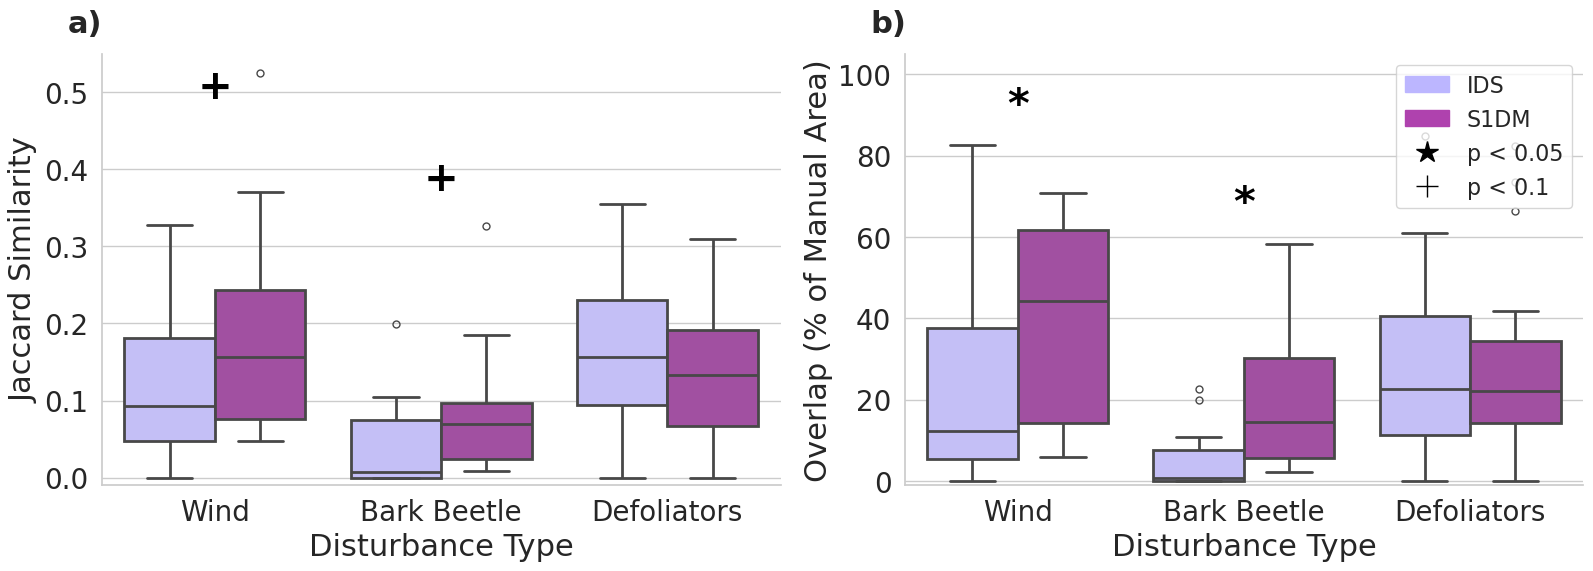

In [66]:
ids = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region_08_dca_filtered_ids_usda_polygons.shp"
s1dm = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp"
manual_base_folder = "/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/data/manual_planet_labels"
analyze_and_plot_manual_significance(ids, 
                                    s1dm, 
                                    manual_base_folder, 
                                    '/',
                                    '/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/figures/F08_p1_f7_significance_manual_test.png'
                                    )